<h1 align="center">GPR Testing</h1>

## **Pip Installs**

pip install matplotlib (3.10.7)

pip install numpy (2.3.5)

pip install scikit_learn(1.7.2)

pip install scipy(1.16.3)

pip install pandas(2.2.3)

In [64]:
# Install the requirements
%pip install matplotlib numpy scikit_learn scipy pandas

## About GPR Algorithm

Think of GPR as a "smart" interpolation method that uses Bayesian probability.
 Instead of fitting a rigid function like a polynomial, you define a kernel, which acts as a prior describing the expected properties of the function (e.g., "I expect this curve to be very smooth").
  The GPR then calculates the most probable function (the "posterior") that fits your observed data points, given those properties. The key benefit is that it doesn't just return a single "best-fit" line;
   it returns a full probability distribution, giving you the mean prediction and a confidence interval (variance) for how certain it is.

## Content of Notebook:

1) Function that Creates a signal(radio astronomy observation)

2) Function that Estimate the Hyperparameters that will be used as initial values for the GPR

3) Function that create a mask at the spectral line area

4) Function that implement the GPR algorithm

5) Background Removal to signals and error estimation

## Import Libraries

In [65]:
import time
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation, gaussian_filter1d, label
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

# We need GPR and Kernels from scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Create Signal(Background + Spectral line + Noise)

In [66]:

class SignalType(Enum):
    POLY=1
    SIN=2
    BOTH=3

def background_creation(freq : np.ndarray ) -> tuple :
    """
    Create a signal with bacground,spectral lines and noise.The whole procedure will be random.

    Args:
        freq (np.ndarray): the frequencies of the signal

    Returns:
        tuple: the spectral line and the full observation
    """
    rng = np.random.default_rng()

    # --- 1)Background Signal Creation ---
    possible_signals = [SignalType.POLY,SignalType.SIN,SignalType.BOTH]
    signal_type = rng.choice(possible_signals)
    background = np.zeros(freq.shape)
    #  --- Creation of Baseline ---
    # is_polyonimal = True -> signal = a(frequencies - (freq1,freqn))^2 + b
    # is_sin = True -> signal = A* sin (ω  * (frequencies - (freq1,freqn)) + phase)
    # is_both = True -> signal = polyonimal + sin

    # Add the sin component if the signal is sin or has both sin and polyonimal compoonents
    if signal_type in (SignalType.SIN, SignalType.BOTH) :
        amplitude = rng.uniform(0.5 , 3)
        omega = 2 * np.pi * rng.uniform(low = 0.1 , high = 0.9)
        phase = rng.uniform(low = 0 , high = 2*np.pi)
        background += amplitude * np.sin(omega*(freq- (rng.uniform(np.min(freq) , np.max(freq))) ) + phase)

    #Add the poly component if the signal is poly or has both poly and sin components
    if signal_type in (SignalType.POLY , SignalType.BOTH):
        a = rng.uniform(low=-2 , high = 3)
        b = rng.uniform(low=3 , high = 7)
        background+= a * (freq-(rng.uniform(np.min(freq) , np.max(freq))))**2 + b

    # --- 2) Noise Creation ---
    noise = rng.normal(0.1 , 0.7 , freq.shape)

    # ---3) Spectral Lines Creation ---
    # The spectral line will have a random mean between 1419.5 - 1421 MHz . random Amplitude between 2-8 and random standar deviation between 0.1 - 0.3
    # Spectra line formula: A * e^((x-m)^2 / 2sigma^2)
    # the spectral line duration on the frequency axes is between 0.2-0.5 MHz. So we generate a number that defines the number of lines and according to the number
    # We set the bounds of the mean so the spectral lines dont cover one each other.
    lines_number = int(rng.uniform(1.6,1.9999))
    spectral_lines = 0
    spectral_areas = {
        1 : [(1418.5 , 1421)],
        2 : [(1418.5,1419.5),(1420,1421)],
        3: [(1418.5,1419),(1419.5,1420),(1420.5,1421)],
    }
    for start,end in spectral_areas.get(lines_number):
        mean = rng.uniform(start,end)
        sigma = rng.uniform(0.05 , 0.1)
        amplitude = rng.uniform(3 , 10)
        spectral_line = amplitude * np.exp(- ((freq-mean)**2) / (2 * sigma ** 2))
        spectral_lines += spectral_line

    return background,spectral_lines,background + noise + spectral_lines


## Estimate HyperParameters

In [67]:
def estimate_hyperparameters(signal: np.ndarray, dx : float) -> tuple :
    """
    Estimate The hyper parameters as close as we can so the GPR can have a good initial estimation.

    Args:
        signal (np.ndarray): The signal
        dx (float): the sampling step

    Returns:
        tuple: the hyper parameters
    """
     # --- Noise std Approach ---
    noise_guess = np.median(np.abs(np.diff(signal)))

    # --- Signal Variance Approach ---
    total_var = np.var(signal)
    signal_var = total_var - noise_guess**2

    # --- Length Scale Approach ---
    # Create the gaussian filter
    linewidth_bins = signal_var
    smoothing_linewidth = 5.0*linewidth_bins
    signal_smooth = gaussian_filter1d(signal,sigma=smoothing_linewidth)

    # center the signal so the autocorrelation is around 0
    y_centered = signal_smooth - np.mean(signal_smooth)
    corr = np.correlate(y_centered,y_centered,mode="full")

    # The result of the mode = full  is symetric.The point in the middle (size//2) is the Lag 0.We are intersted in the distance as we move forward(Lag >=0).
    corr = corr[corr.size//2:]

    # Normalize the data of the correlation with the lag 0 (corr[0]) because at lag 0 the signal completely identifies with itself and the value is the variance of the signal.
    # We want a coefficient from 0 to 1 therefore doing corr/=corr[0] we force the curve to start from 1
    corr /=corr[0]

    # we save the indexes that has correlation < 0.368
    one_e = 0.368
    below = np.where(corr<one_e)[0]


    if len(below)>0 :
        # We will define the interpolation boundaries

        idx2 = below[0] # The first point under the 0.368
        idx1 = idx2 - 1 # The last point over 0.368

        if idx1 < 0:
            #If the correlation was under 0.368 at the first step then the signal is almost just noise so we return the minimum possible length
            return noise_guess,signal_var,dx

        # Calculate the sub-pixel accuracy
        # The curve is a line between two points and we find where 0.368 is located in this line
        fraction = (corr[idx1]- 0.368/corr[idx1] - corr[idx2])

        #isx1 + fraction is the position of the length_scale in pixels
        return noise_guess , signal_var , (idx1+fraction)*dx

    # if the correlation was never below 0.368
    return noise_guess , signal_var , np.nan

## Implementation of the spectral line mask

### Method : **Rolling Median + MAD**

This method contains 3 steps:

Implementation Steps:

Calculate a Rolling Median to estimate the background while ignoring the peaks.

Calculate the MAD (Median Absolute Deviation) to estimate the noise level 
robustly.

Create a boolean mask where $|Data - Median| > Threshold \times \sigma_{MAD}$.

### Parameter Tuning

The main issue is the choice of the window size.The window must be wider than the spectral line (to avoid fitting the line) but narrower than the background curvature (to follow the baseline).

The choice of 1MHz as the window size is explained:

The bandwidth of the signal is 4MHz and if set as a target the Hydrogen line(HI) the simulated width of the line is approximantly 0.6 MHz.So the number 1 is enough to cover the spectral line and it also provides a safety margin

Using a threshold of 1 adopts an aggressive strategy: 'Flag any potential signal candidates (anything above 1σ) and rely on the size filter to discard isolated noise artifacts.'"

### Essential Mask Refinements for Optimal GPR Performance

Problem Definition: **The Edge Contamination Effect**. Once the initial mask is generated, a critical challenge arises regarding the Gaussian Process Regressor's (GPR) behavior within the masked gap. The GPR relies on the data immediately surrounding the gap to interpolate the missing values.

If the mask is not sufficiently wide, the GPR detects the "wings" (the rising and falling edges) of the spectral line at the boundaries of the mask. Consequently, the algorithm infers that an upward, convex curve exists within the gap, leading to an overestimation of the background power (an artificial "bump"). To prevent this, the mask must be widened (dilated) to completely obscure the spectral line's profile from the algorithm.

Implementing a blind expansion of the mask introduces a secondary issue. To ensure we capture the base of the spectral line, we utilize a deliberately low detection threshold (e.g., $1\sigma$). While effective for the signal, this aggressive threshold inevitably flags numerous isolated noise spikes across the spectrum as "masked" data. Expanding these random noise artifacts would fragment the dataset with unnecessary gaps, destabilizing the GPR.

The Solution: **Size Filtering (Morphological Cleaning)** To resolve the conflict between the need for a wide mask and the preservation of the noise floor, we implemented a Size Filtering mechanism (Connected Component Analysis):

Identification: The algorithm identifies continuous clusters of masked points.

Filtration: Clusters containing a small number of consecutive points are classified as random noise and are unmasked. Only large, continuous regions (characteristic of the spectral line) are retained.

Safe Dilation: With the noise artifacts removed, the mask now isolates only the spectral line.

This approach achieves two vital goals:

It leaves the general noise floor intact, allowing the GPR to accurately utilize the pre-calculated noise_level hyperparameter without statistical distortion.

It permits us to aggressively expand (pad) the mask around the spectral line without the risk of expanding noise artifacts, effectively solving the edge contamination problem.

### !

For the Rolling Median and MAD method we need three vales to define:

1) How many points of the start and end of teh signal we will not let to be masked ? 
2) Below how many consecutive points do we consider noise and not spectral?
3) How far do we need to extend the mask to completely cover the line area?

After many tries for samples = 1024 we have conclude to :
1) 50
2) 15
3) 25

So we can make this method adaptive by selecting these numbers:
1) 50/1024 *100 % = 4.88 % of samples
2) 15/1024 *100 % = 1.46 % of samples
3) 25/1024 *100 % = 2.44 % of samples

!!!However we tried it with different siganls and it didnt work , the masking method was unsuccesfull and GPR trained with all the signal , so the static values are better than making an analogy according to samples

## Rolling Median and MAD

In [68]:
def spectral_mask(y_observed: np.ndarray , freq : np.ndarray ) -> np.ndarray :
    """
    Create a mask to hide the spectral line data from the GPR Algorithm,implement rolling median and MAD filter.

    Args:
        y_observed (np.ndarray): The signal
        freq (np.ndarray): The frequencies axes

    Returns:
        np.ndarray: The mask
    """
    # Define the window and threshold according to the explanation above
    window_width_freq = 1 # MHz
    threshold_sigma = 1

    # Step 1: Convert the window width from MHz to bins(points) by finding the resolution
    freq_step = np.abs(freq[1] - freq[0])
    window_bins = int(window_width_freq / freq_step)

    # The window must be odd number
    if window_bins % 2 == 0:
        window_bins += 1

    # 2. Estimate Rolling Median
    y_series = pd.Series(y_observed)
    rolling_median = y_series.rolling(window=window_bins, center=True, min_periods=1).median().to_numpy()

    # 3. Estimate the Residuals
    diff = np.abs(y_observed - rolling_median)

    # 4. Estimation MAD (Median Absolute Deviation) and Sigma
    #  MAD show how much noise the signal has
    mad = np.median(diff)

    # Convert MAD to standar deviation (sigma) for normal distribution
    sigma = 1.4826 * mad

    # 5. Create Mask

    #Use the filter to all the signal
    """
    mask = diff > (threshold_sigma * sigma)

    """
     #Use the filter only between 1419 , 1421.3
    """
    mask = np.array(np.zeros_like(y_observed,bool),dtype=bool)
    for i in range(len(mask)):
        if(freq[i] >=1419 and freq[i]<=1421.3) and diff[i]>threshold_sigma*sigma:  # noqa: PLR2004
            mask[i]=True
    """

    # The points where the differnecies bigger from the threshold we set it true(masked)
    mask = diff>(threshold_sigma*sigma)
    # Remove the mask from the start and end of the signal
    mask[:50]= False
    mask[-50:] = False


    # 6. Remove the use of the filter at small areas which is noise
    # Method: (Size Filtering)

    # Create a unique label for each unique feature
    labeled_array , _num_features = label(mask)

    # Count number of occurrences of each value
    component_sizes = np.bincount(labeled_array.ravel())

    # Check which IDs have small duration,smaller than 15 points
    small_threshold = 15
    small_duration_components = component_sizes < small_threshold

    # Create the array that will show us which positions in our initial mask are noise and not the line area
    small_components_mask = small_duration_components[labeled_array]

    # Clean the mask
    clean_mask = mask.copy()
    clean_mask[small_components_mask] = False

    # Mask the beggining and the end of the spectral line so the GPR fills the gap with the background behaviour
    padding = 35

    # add 30 points at the start and at the end of the line's mask
    return binary_dilation(clean_mask,iterations=padding)



## Baseline Correction (Residual Detrending)

### 1. Motivation & Problem Definition
While Gaussian Process Regression (GPR) excels at modeling the non-linear curvature of the background, it often suffers from a **"Floating Baseline" artifact**. This manifests as a systematic offset (bias) where the estimated background is vertically shifted relative to the true noise floor.
* **Effect:** If the baseline is estimated too high, the extracted spectral lines appear "shorter" (negative bias). If too low, they appear "taller".
* **Goal:** To align the noise floor of the extracted signal exactly to zero, thereby recovering the true flux of the spectral peaks.

### 2. The Algorithm: Morphological Wing Detection
To correct this bias, we perform a **Linear Detrending** on the residuals. However, instead of simply taking the start and end of the spectrum, we must identify the "edges" (noise-only regions) adjacent to **every** spectral feature.

We utilize **Morphological Dilation** to automatically identify these anchor points, regardless of the number of spectral lines or their positions.

#### Mathematical Logic
Let $M$ be the boolean mask where $M=1$ indicates signal and $M=0$ indicates noise.
We define the **"Edges Mask"** ($W$) as the region immediately surrounding the signal, calculated as:

$$W = \text{Dilation}(M, k) \cap (\neg M)$$

Where:
* $\text{Dilation}(M, k)$: Expands the True regions of mask $M$ by $k$ pixels (the `wing_width`).
* $\neg M$: Is the inverse of the original mask (only noise regions).
* $\cap$: Represents the logical AND operation.

**Result:** The set $W$ contains valid noise samples from the "shores" of **every** spectral island, including the gaps between multiple lines.

### 3. Execution Steps
1.  **Edges Extraction:** We apply the morphological operation described above to select valid anchor points ($f_{wing}, y_{wing}$).
2.  **Least Squares Fit:** We assume the GPR error $\epsilon(f)$ is locally linear. We solve for slope $\alpha$ and intercept $\beta$ that minimize the error in the wing regions:
    $$\min_{\alpha, \beta} \sum_{i \in W} \left( Y_{ext}(f_i) - (\alpha f_i + \beta) \right)^2$$
3.  **Correction:** The calculated linear trend is subtracted from the **entire** frequency bandwidth:
    $$Y_{final}(f) = Y_{ext}(f) - (\hat{\alpha} f + \hat{\beta})$$

### 4. Parameter: `edge_width`
This parameter defines the sample size for the correction.
* **Recommended Value:** `20-30` channels.
* **Justification:** A width of ~30 ensures enough statistical samples to average out Gaussian noise ($\propto 1/\sqrt{N}$), preventing the fit from being skewed by random noise spikes, while remaining small enough to maintain the assumption of local linearity.

In [69]:

def calculate_baseline_error(frequencies: np.ndarray,extracted_signal: np.ndarray,mask: np.ndarray,edge_width: int = 30) -> np.ndarray:
    """
    Estimate the linear error of the GPR using the area's before and after the spectral line's so
    the offset of the GPR Background can be substracted.

    Args:
        frequencies (np.ndarray): The frequency axes
        extracted_signal (np.ndarray): The spectral line's(y_observed - baseline_gpr)
        mask (np.ndarray): the mask of the siganl in the spectral lines
        edge_width (int, optional): The sample size for the correcction. Defaults to 30.

    Returns:
        np.ndarray: the linear error for all the signal
    """
    # Create the area with the edges of the spectral lines (Edges Mask)
    # We add to our mask 30 points for every masked area so we can keep the edges
    dilated_mask = binary_dilation(mask, iterations=edge_width)

    # The edges are the differnece between the original mask and the extended mask
    # We keep the points that are near the lines but not in the lines
    edges_mask = dilated_mask & (~mask)
    x_fit = frequencies[edges_mask]
    y_fit = extracted_signal[edges_mask]

    # If we didnt manage to find edges then we return zero error
    if x_fit.size==0:
        return np.zeros_like(extracted_signal)
    # Least Squares
    # We find the line that fits all the edges
    coeffs = np.polyfit(x_fit, y_fit, deg=1)

    # 5. Create the line
    error_line_func = np.poly1d(coeffs)

    return error_line_func(frequencies)

## Gaussian Fitting

In [70]:
def gaussian(x : np.ndarray, amp : float, mean : float, sigma : float) -> np.ndarray :
    """
    _Implement Gaussian type function.

    Args:
        x (_type_): Frequency axes
        amp (_type_): amplitude
        mean (_type_): The frequency that represents the mean of the spectral line
        sigma (_type_): Standard Deviation

    Returns:
        _type_: spectral line
    """
    return amp * np.exp(-((x - mean)**2) / (2 * sigma**2))

def gaussian_fit(x_train : np.ndarray , y_train : np.ndarray) -> np.ndarray:
    """
    Fit the gaussian spectral line.

    Args:
        x_train (np.ndarray): frequency axes
        y_train (np.ndarray): signal with the spectral line

    Returns:
        np.ndarray: The fitted spectral line
    """
    # First estimation
    amp_guess = np.max(y_train)
    mean_guess = x_train[np.argmax(y_train)]
    sigma_guess = 0.05 # from many tries the sigma is around 0.03-0.08 so we set 0.05 as a starter
    p0 = [amp_guess,mean_guess,sigma_guess]

    # use curve_fit to fit the spectral
    popt , _ = curve_fit(gaussian , x_train , y_train , p0=p0)
    print(f"p0 = {p0}")
    print(popt)
    return gaussian(x_train,*popt)




## Implementation of the GPR Algorithm

We want to approximate the background and subtract it from the total observation to find the spectral line. So it is important to emphasize how we will handle the observation and specifically the spectral line.

The option of the mask provides many usefull functions for our pipeline.First we help the algorithm t fit the background and we dont confuse the algorithm with the existance of the spectral line.As a result we have a better performance and the speed of the algorithm is remarkable comapred to other uses of GPR like iterative mask or kernels mixture.Nevertheless in an automated pipeline the mask is not the best solution.However through many efforts and experimentation, we have thus adapted the mask method, which is extremely effective for different signals.


In [71]:
def gpr_algorithm( freq : np.ndarray, freq_train:np.ndarray , signal_train : np.ndarray, hyperparameters : list) -> np.ndarray :
    """
    Implement the GPR algorithm to find the background observation , with the use of mask at the spectral line.

    Args:
        freq (np.ndarray): the frequency axes
        freq_train (np.ndarray): the masked frequency axes
        signal_train (np.ndarray): the masked signal
        hyperparameters (list) : a list that contains a tuple (noise_guess , signal_var , length_scale_estimation)

    Returns:
        np.ndarray: the background
    """
    # Extract the hyperparameters from the list
    noise_guess , signal_var , length_scale_est = hyperparameters[0]
    # --- DEFINE THE KERNELS ---
    # 1) Background Kernel (Smooth)
    # Bounds : From /6 to 50 *.We prevent the algorithm to overfitt by setting the lower bound like this.The upper bound doesnt affect.
    # signal_var -> first estimation in the amplitude of the signal
    # length_scale -> for how many data points the data is relative, we use the estimation we have
    # length_scale_bounds  -> let the optimizer try values
    # As for the kernel we use RBF for smooth signals(if the background was spiky and not smooth we would use Matern)
    kernel_foreground = signal_var*RBF(length_scale=length_scale_est,length_scale_bounds=(length_scale_est/6,length_scale_est*50))

    # 2) Noise kernel
    noise_kernel = WhiteKernel(noise_guess , noise_level_bounds=(noise_guess*0.5,noise_guess*2))

    # 3) Combine the kernels because GPR needs the combined kernel
    total_kernel = kernel_foreground+noise_kernel

    # --- Implementation of the GPR Algorithm ---
    gpr = GaussianProcessRegressor(kernel=total_kernel,alpha=0,optimizer="fmin_l_bfgs_b",n_restarts_optimizer=3)
    # aplha = 0 : we use a noise kernel so we dont need to add alpha
    # optimizer restart = 3 -> we make an estimation at the hyperparameters before we use the GPR. So we dont need 5 or 10 restarts because
    # GPR finds the optimized values fast because we provide a very good initial values

    # --- Fiiting the signal ---
    gpr.fit(freq_train,signal_train)

    # return the predicition of the GPR for the background
    return gpr.predict(freq.reshape(-1,1))


p0 = [np.float64(9.439802014690848), np.float64(1420.6588465298144), 0.05]
[9.31746476e+00 1.42065528e+03 7.85736781e-02]


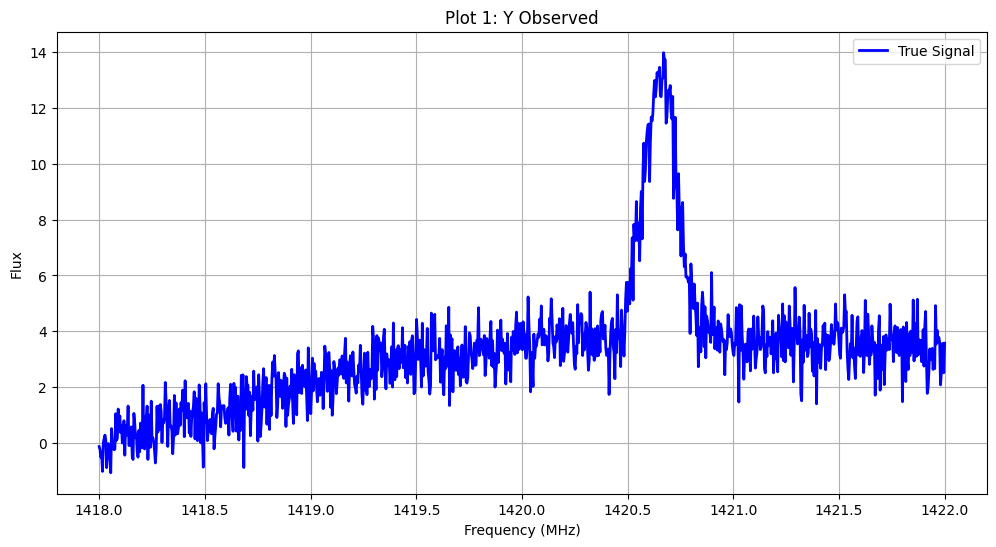

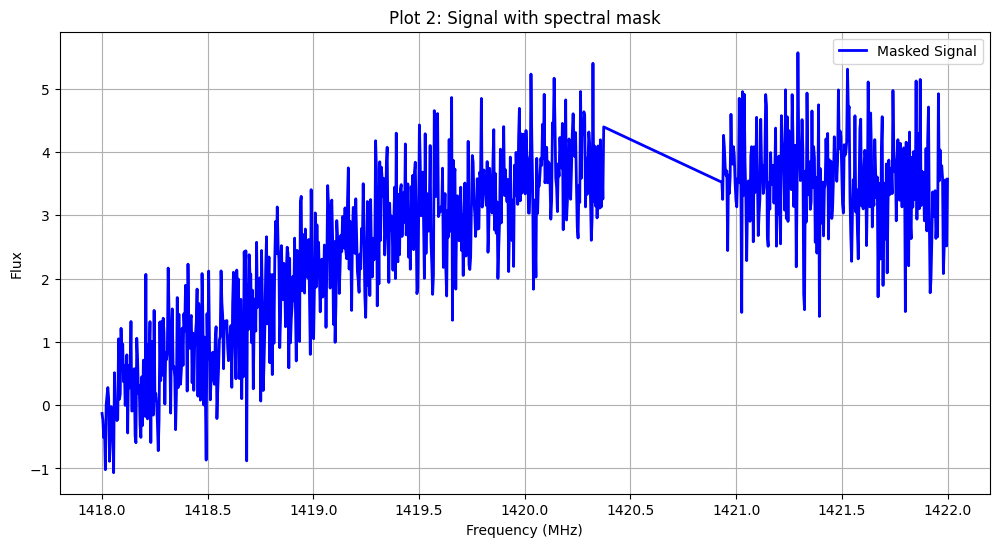

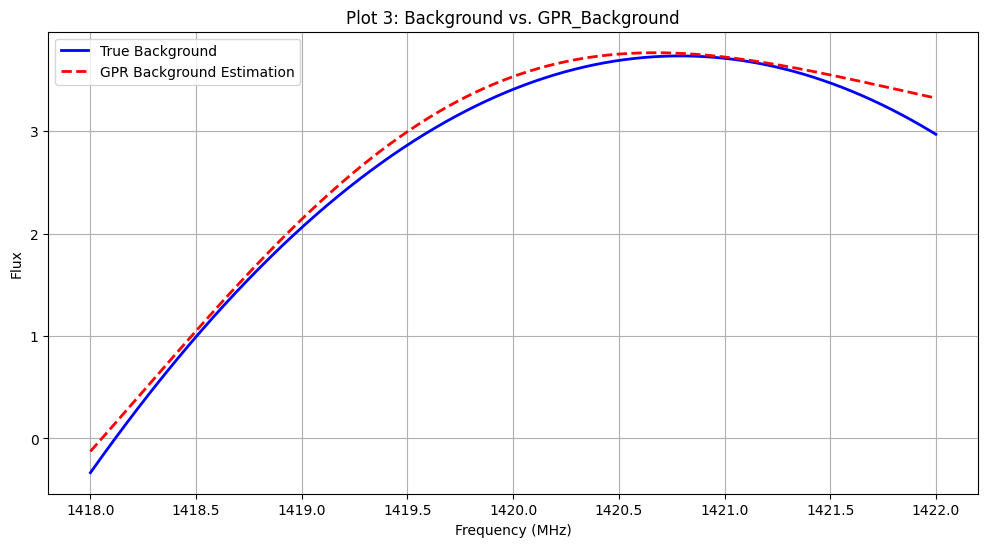

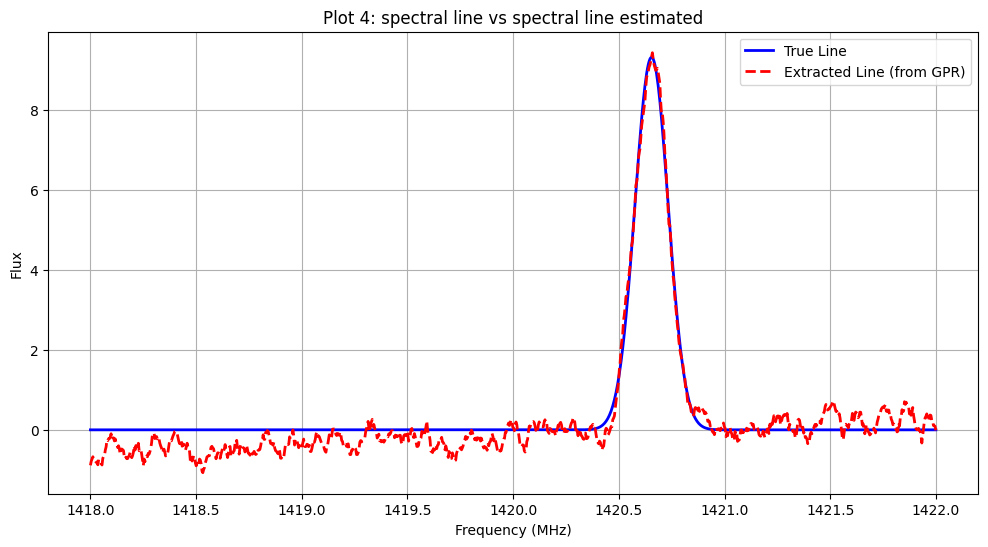

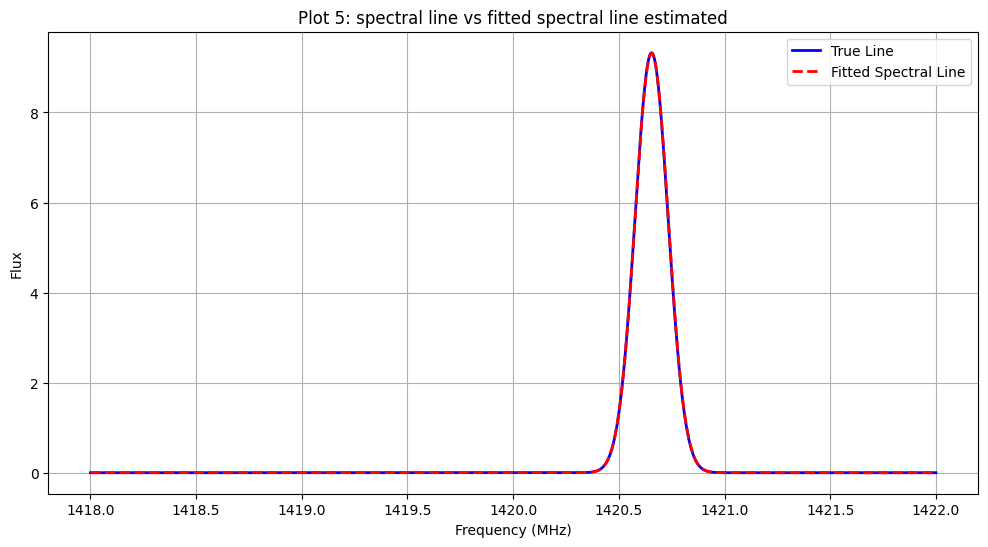

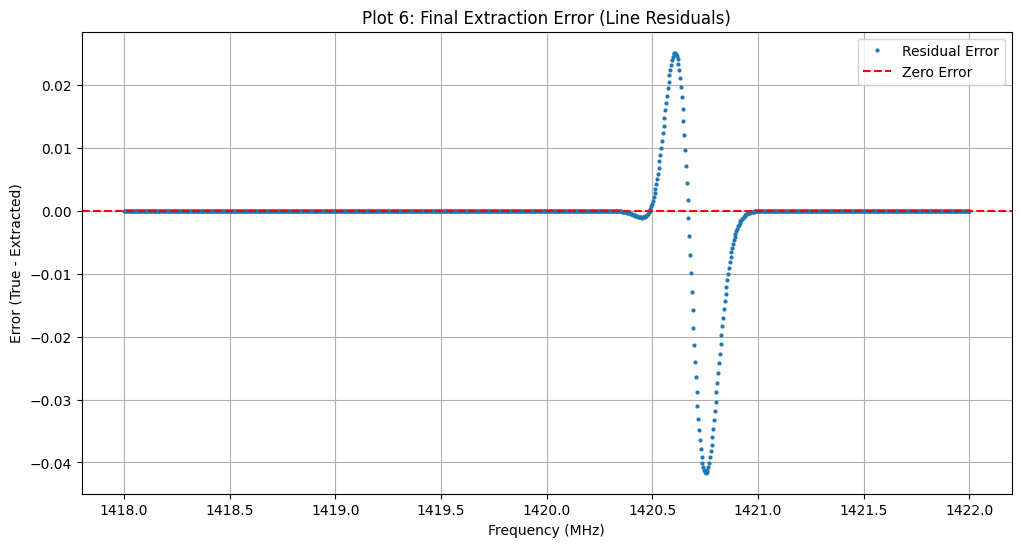

p0 = [np.float64(5.822991108553592), np.float64(1418.629521016618), 0.05]
[5.69903163e+00 1.41862826e+03 7.92643700e-02]


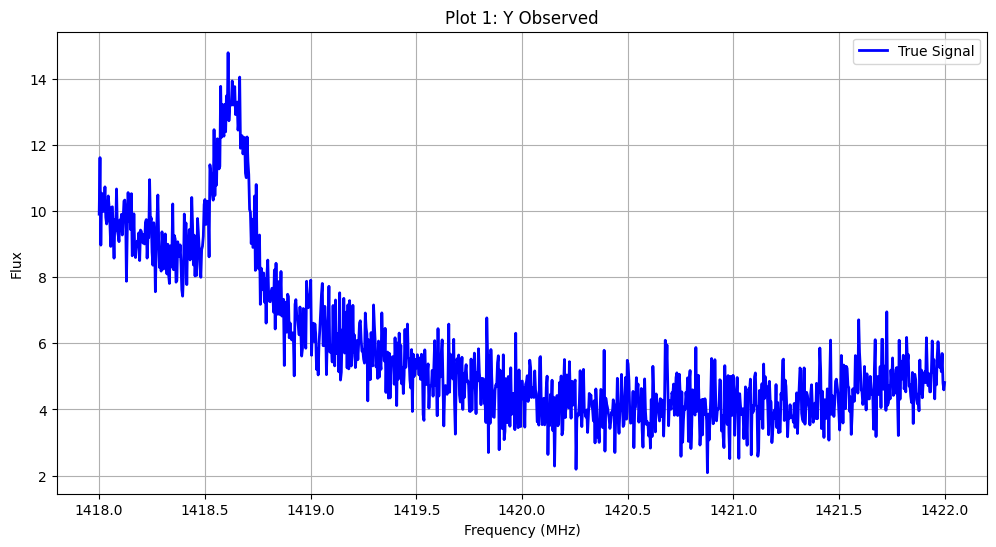

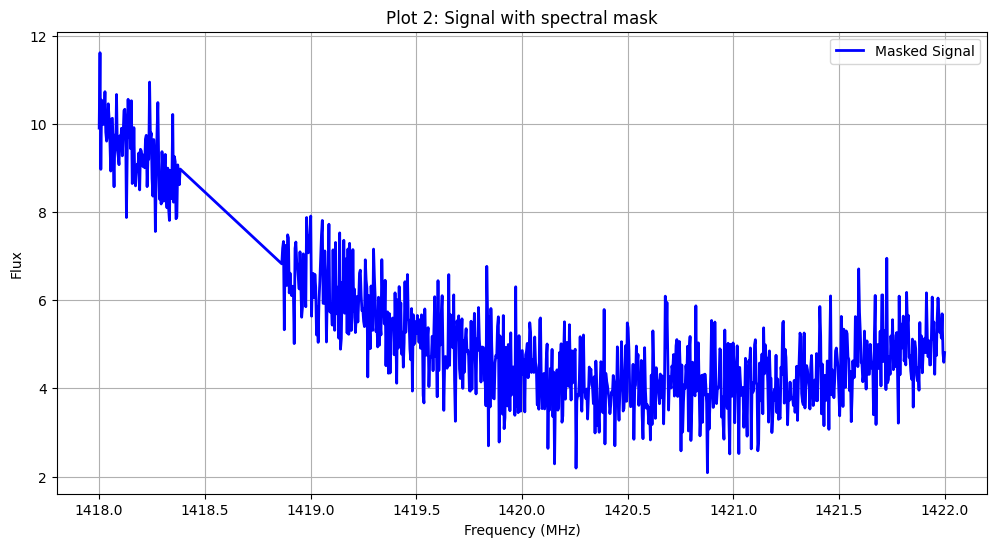

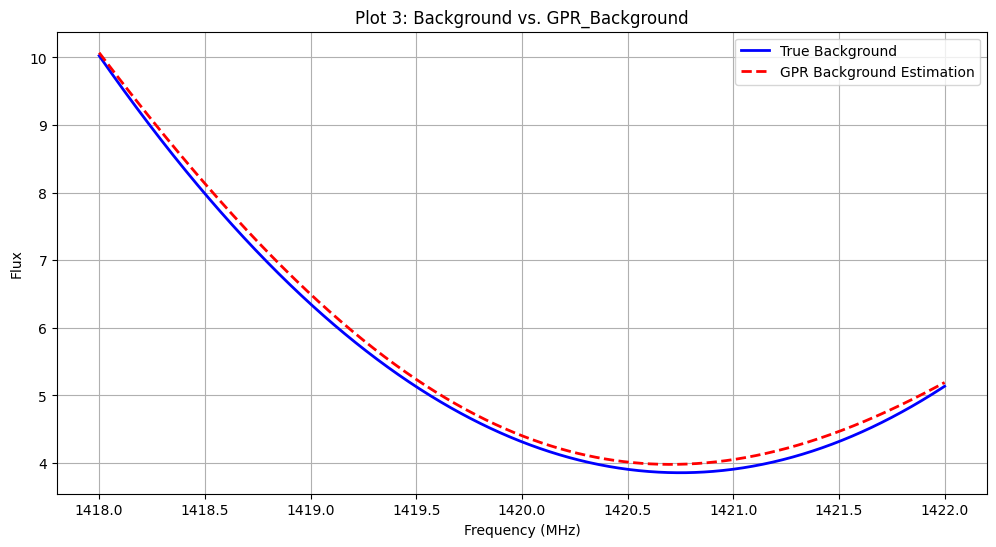

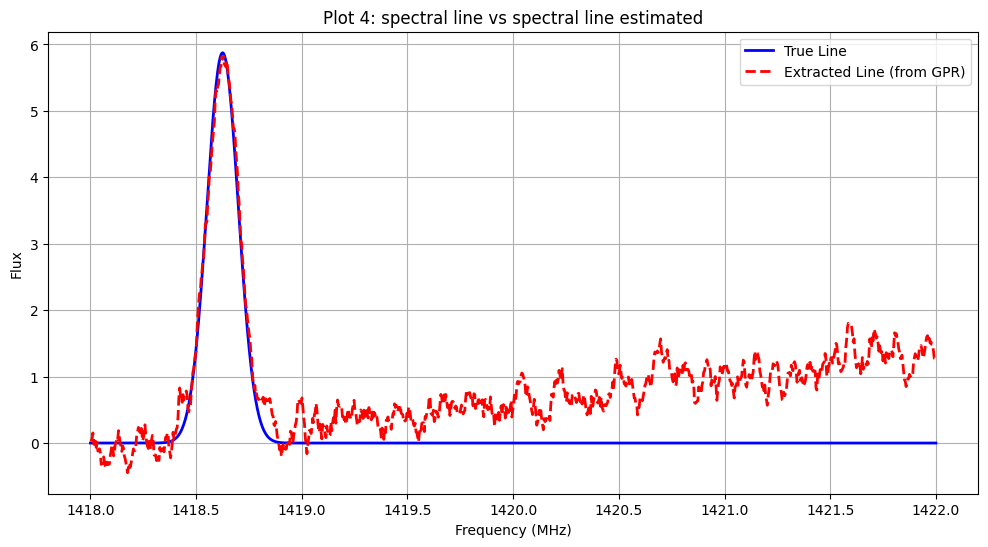

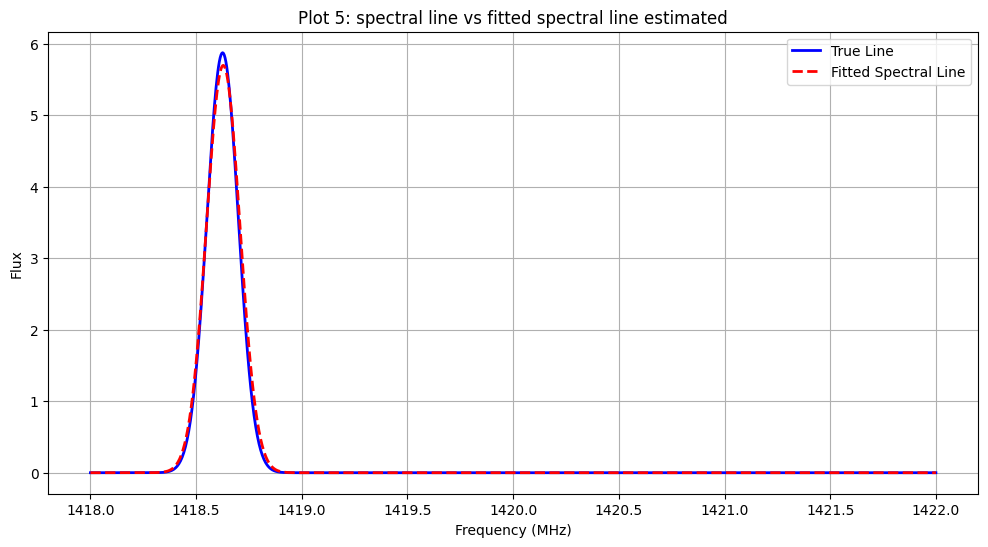

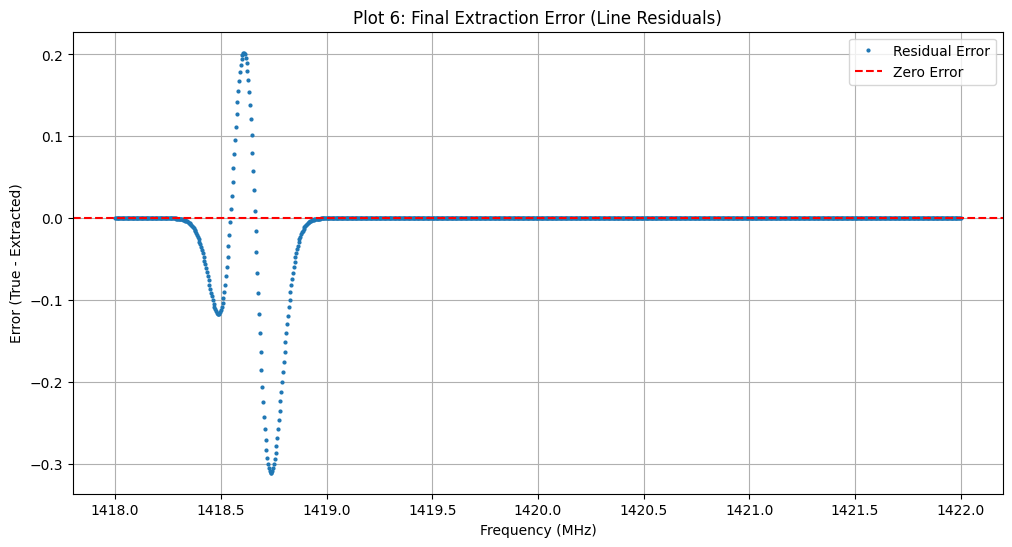

p0 = [np.float64(3.3676053309321308), np.float64(1420.9990224828935), 0.05]
[3.40292134e+00 1.42098489e+03 5.03962440e-02]


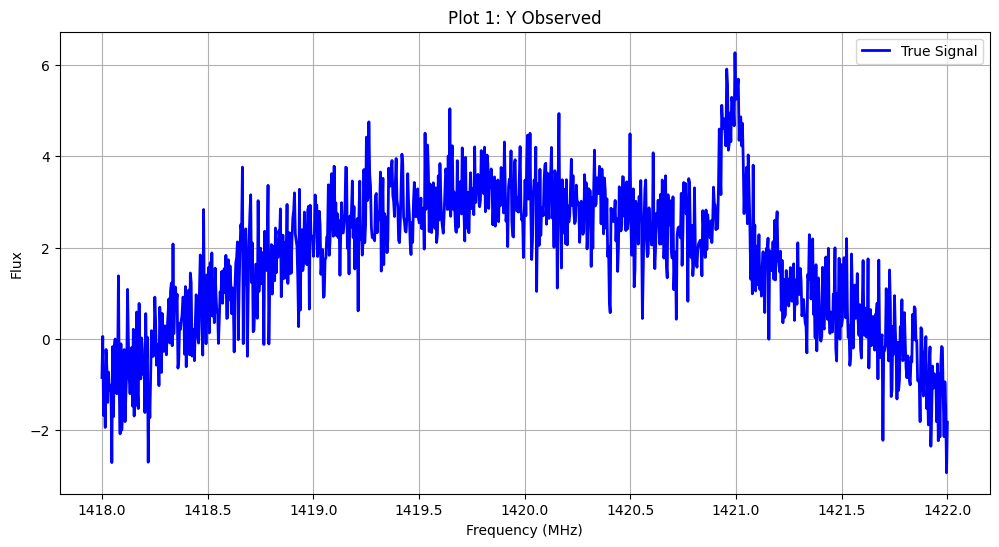

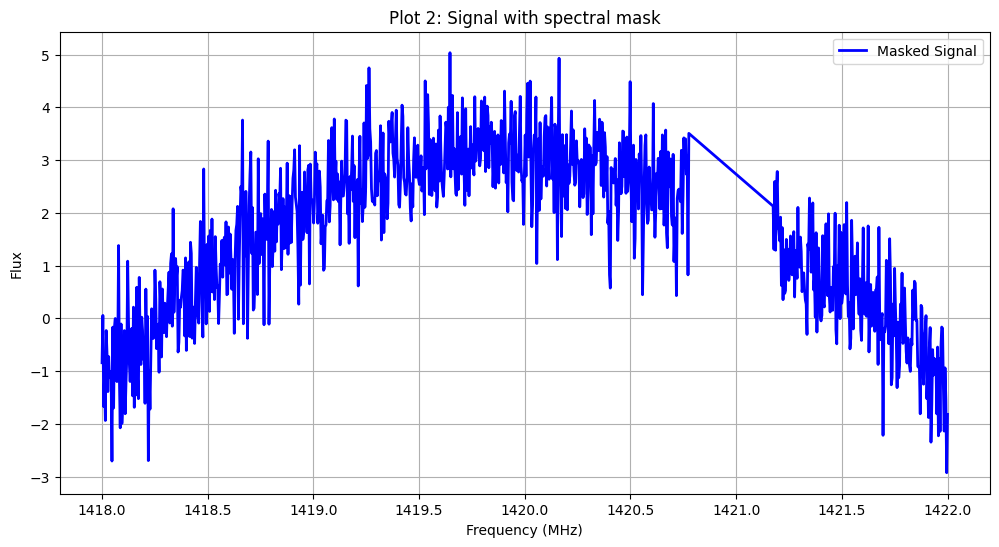

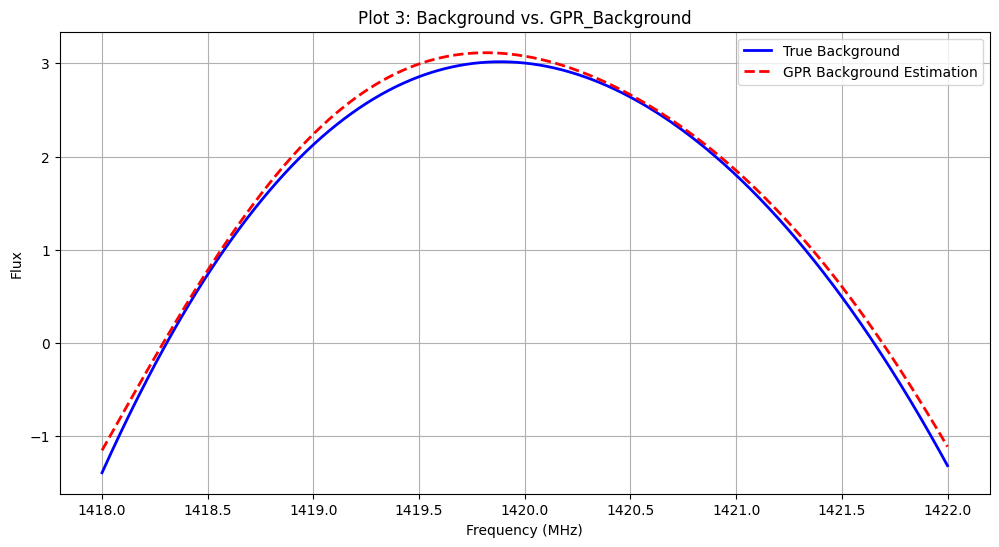

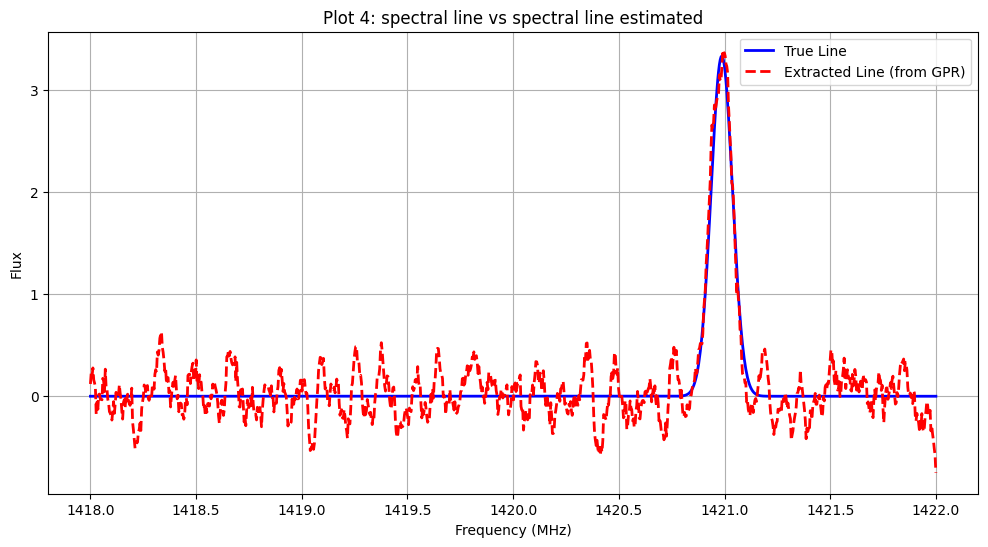

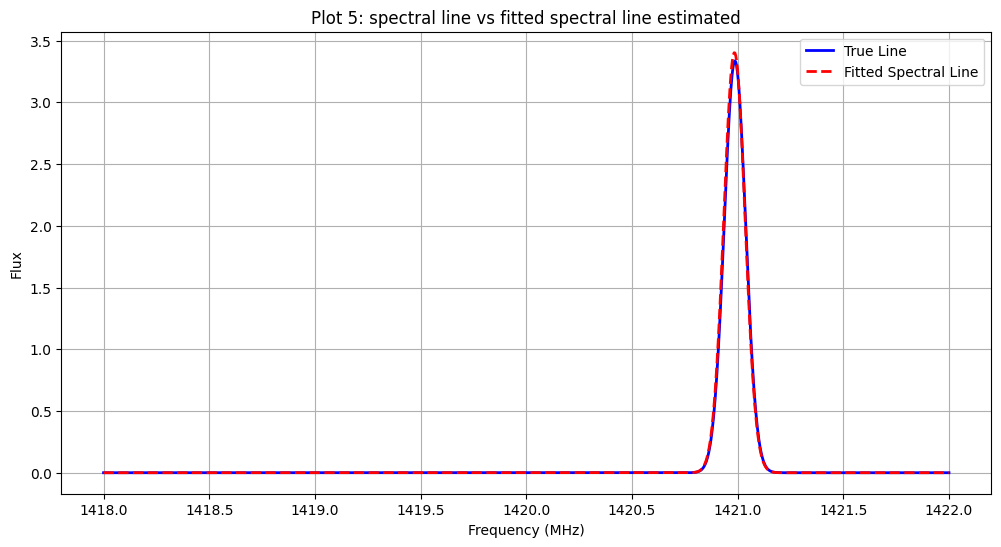

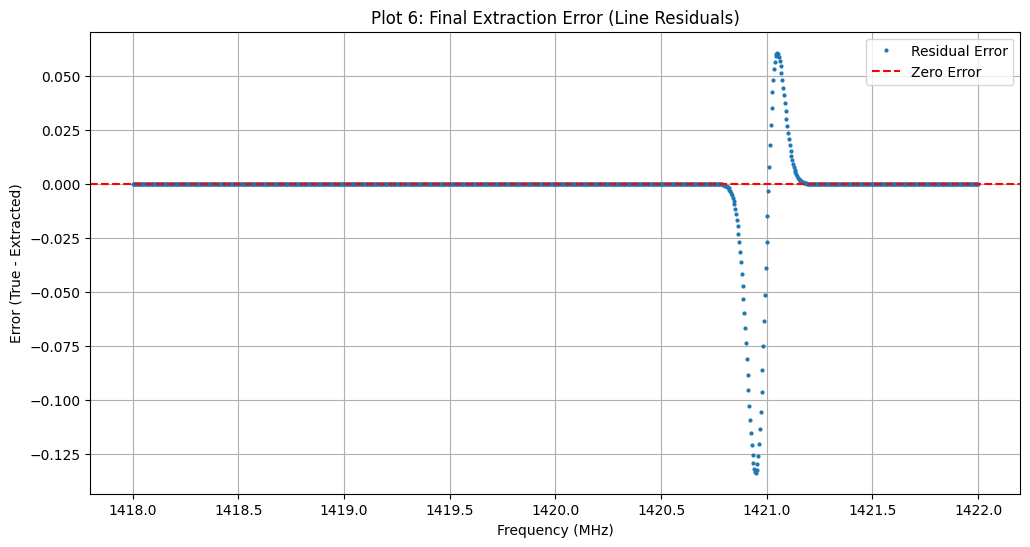

p0 = [np.float64(8.195029765626419), np.float64(1419.2043010752689), 0.05]
[8.16851994e+00 1.41921024e+03 6.55674991e-02]


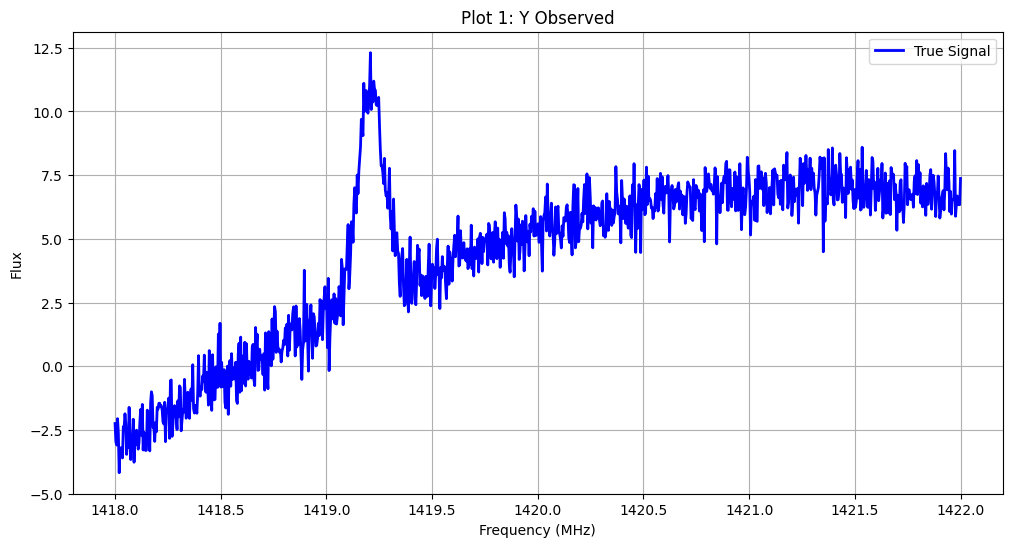

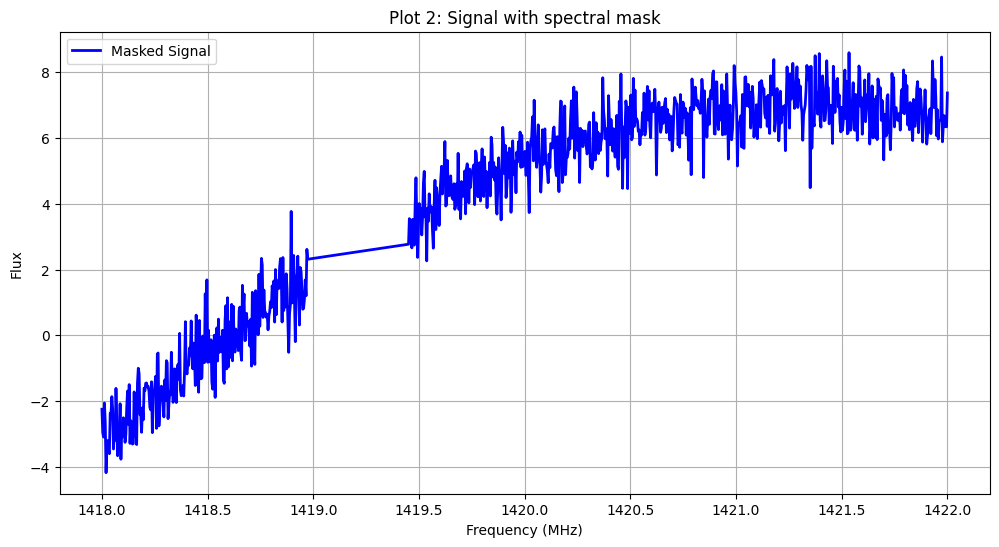

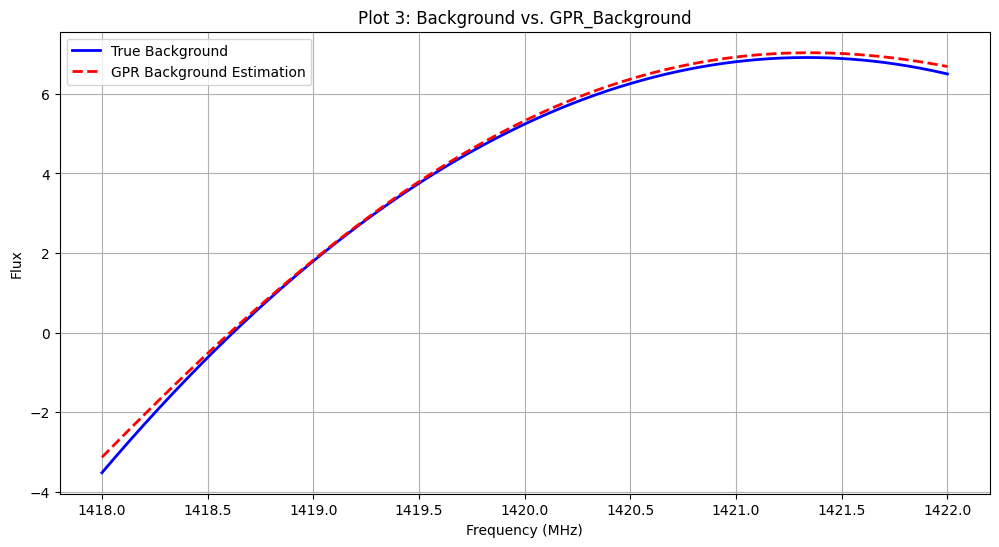

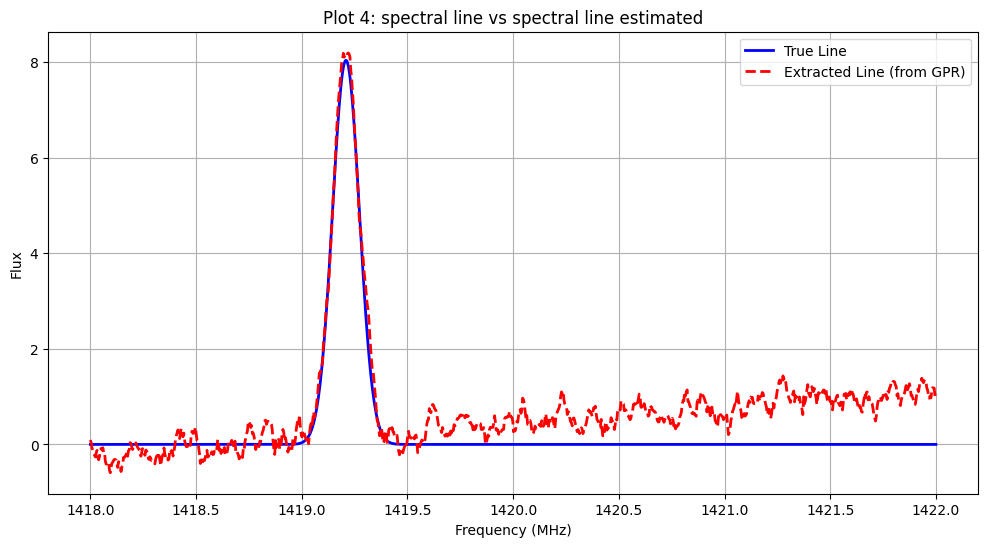

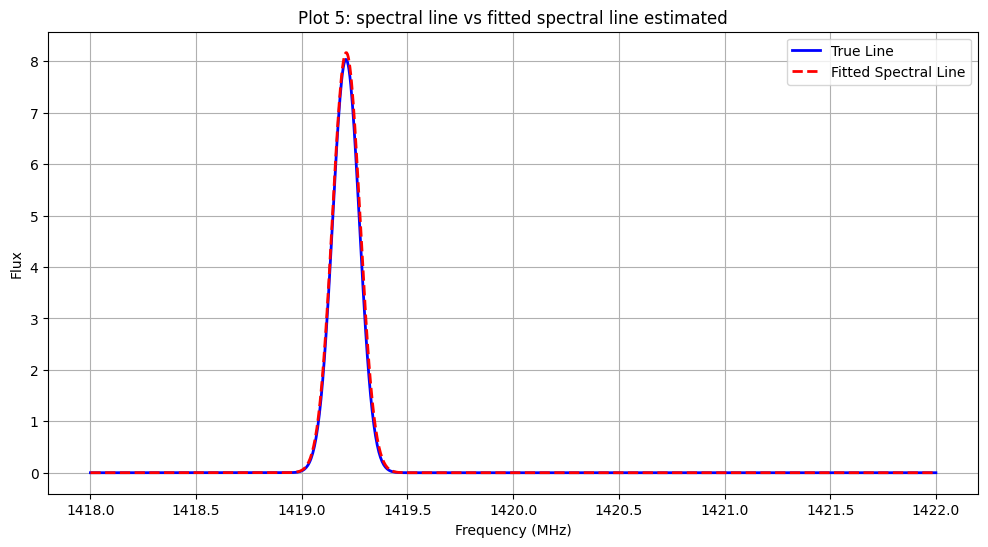

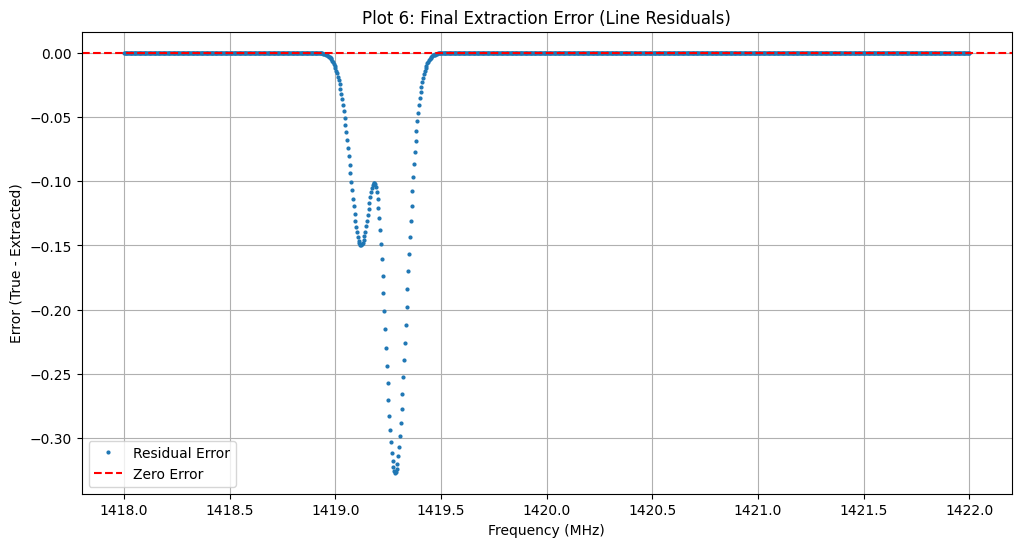

p0 = [np.float64(6.303565391907148), np.float64(1420.197458455523), 0.05]
[6.60693192e+00 1.42020416e+03 8.39966507e-02]


C:\Users\pakak\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.11210865496807908. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


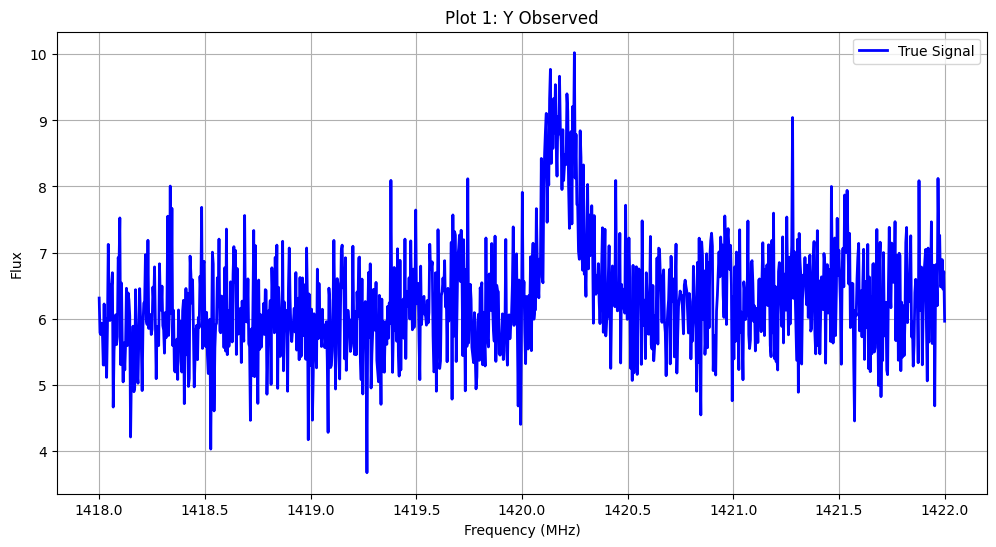

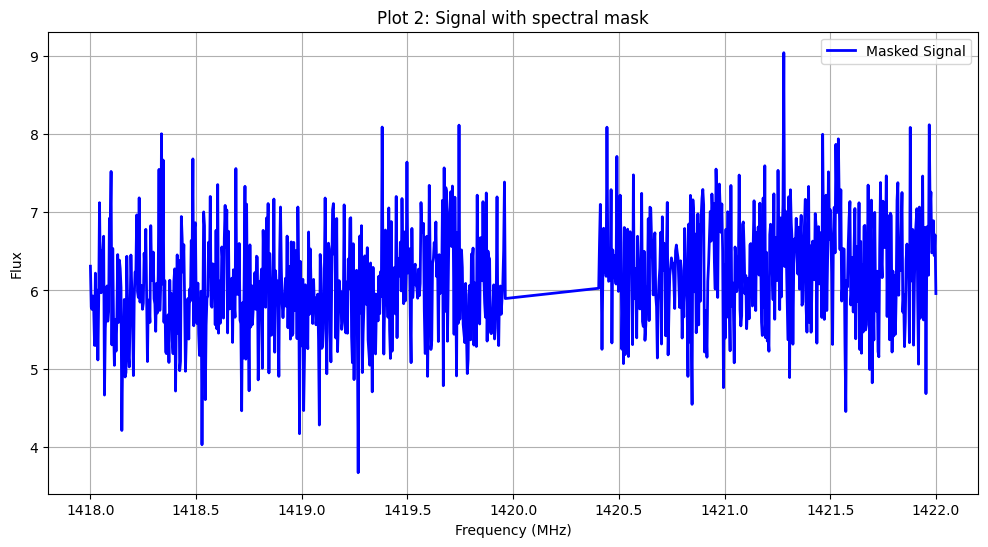

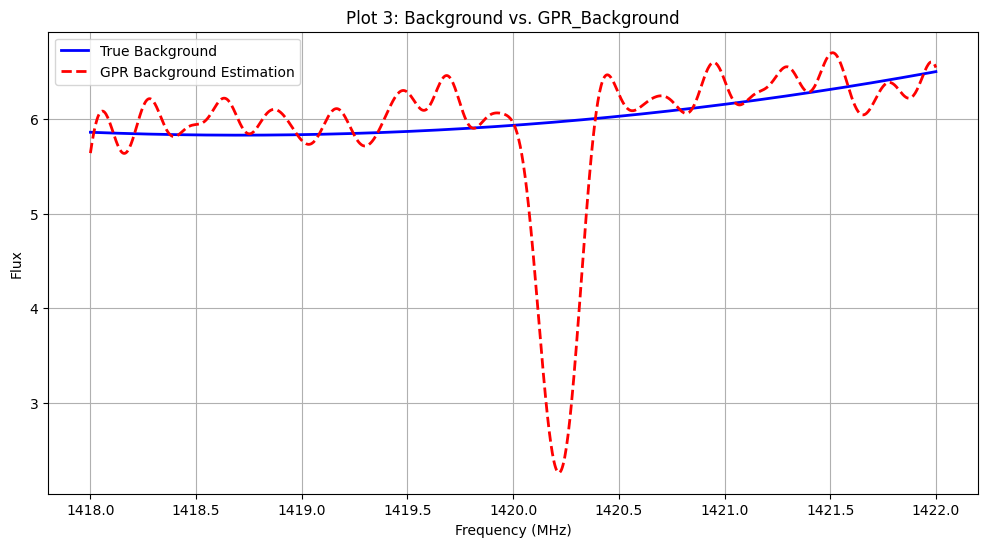

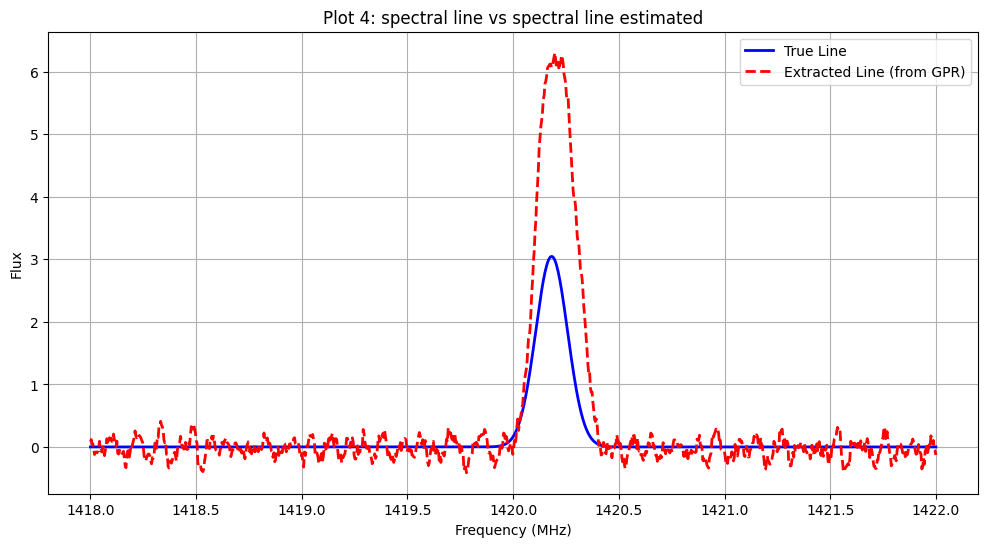

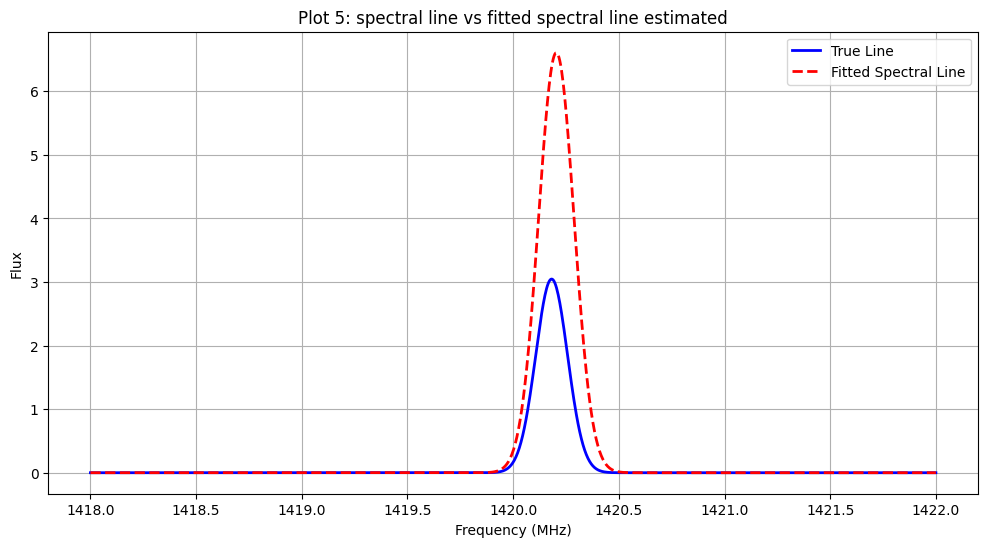

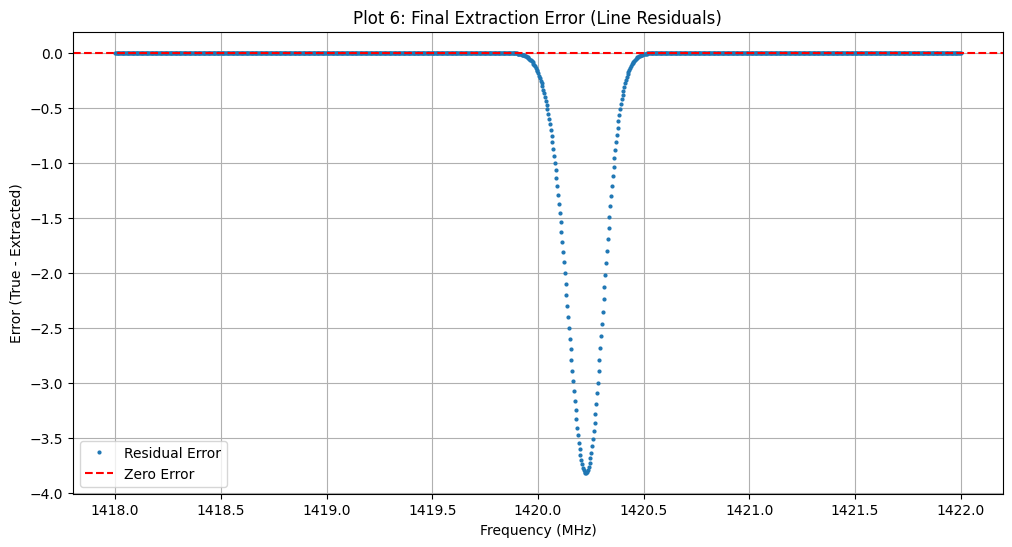

p0 = [np.float64(6.5103698583215825), np.float64(1420.8856304985338), 0.05]
[6.54482467e+00 1.42088112e+03 6.94976970e-02]


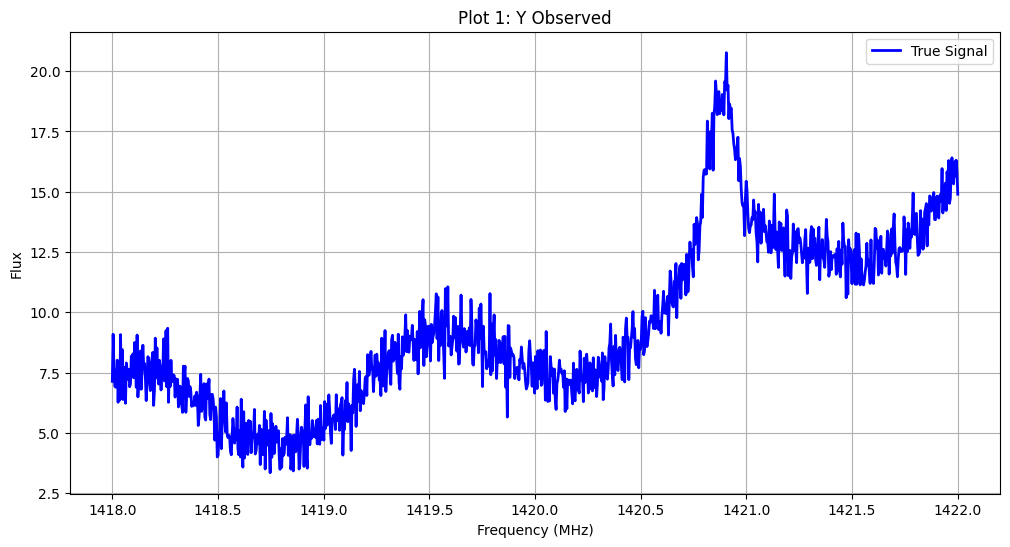

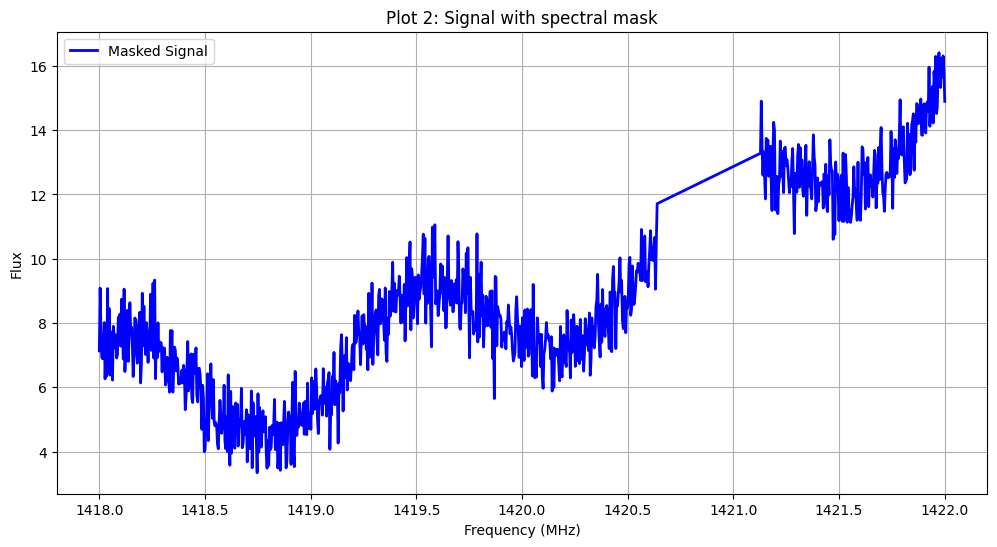

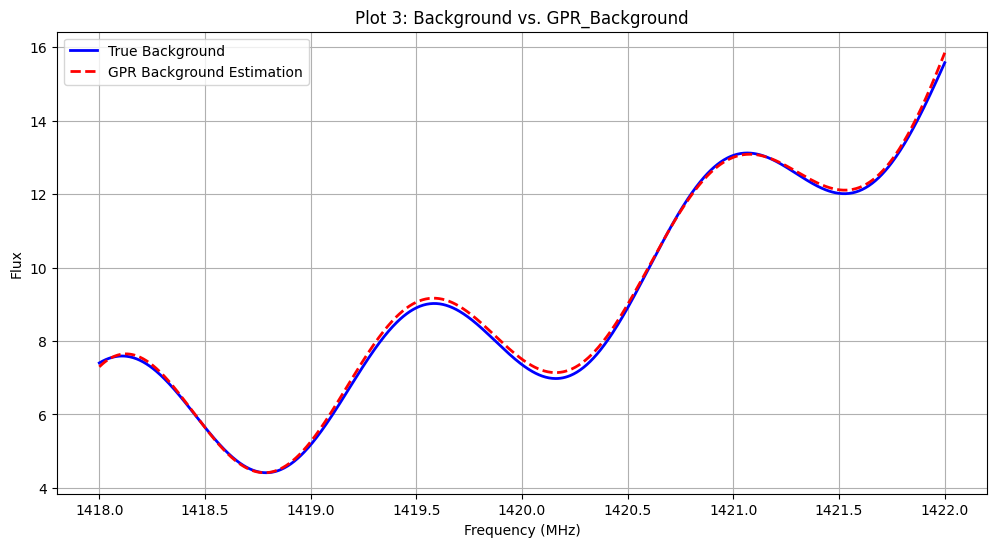

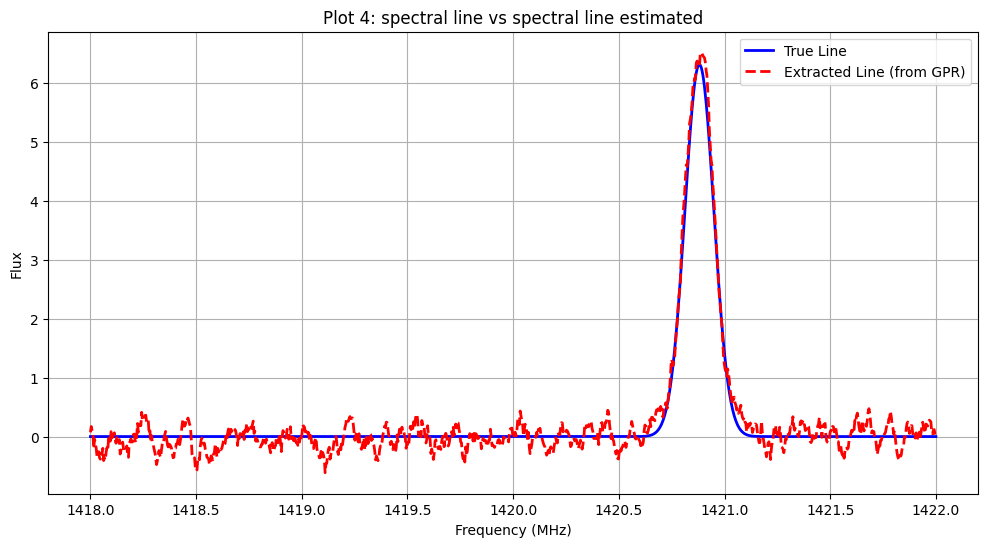

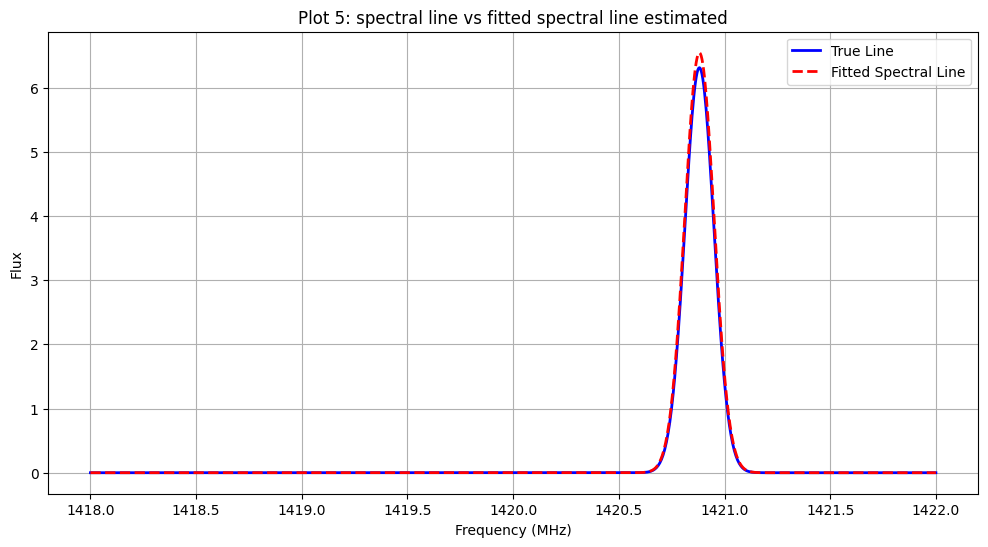

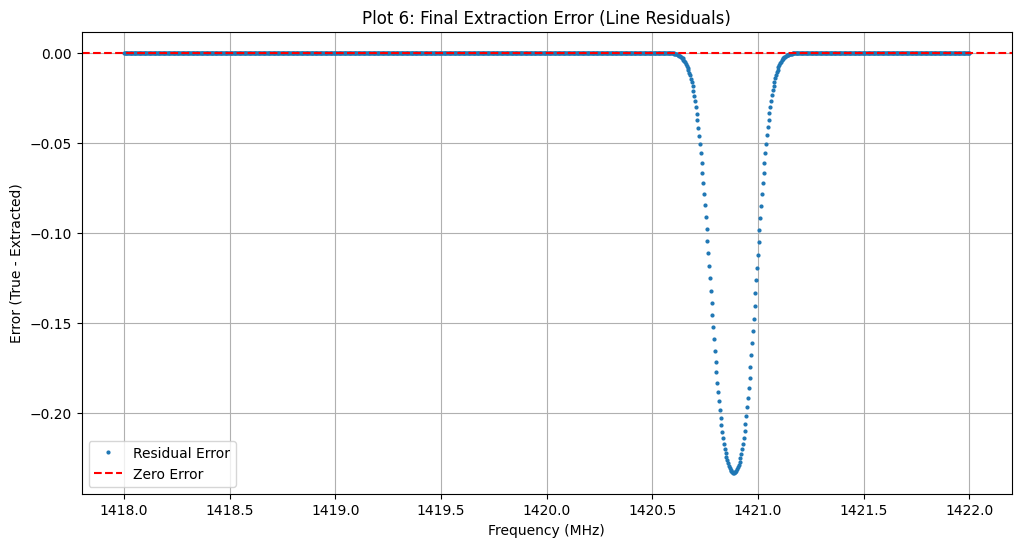

p0 = [np.float64(5.943789474206702), np.float64(1420.8074291300097), 0.05]
[5.82090150e+00 1.42080301e+03 5.81161258e-02]


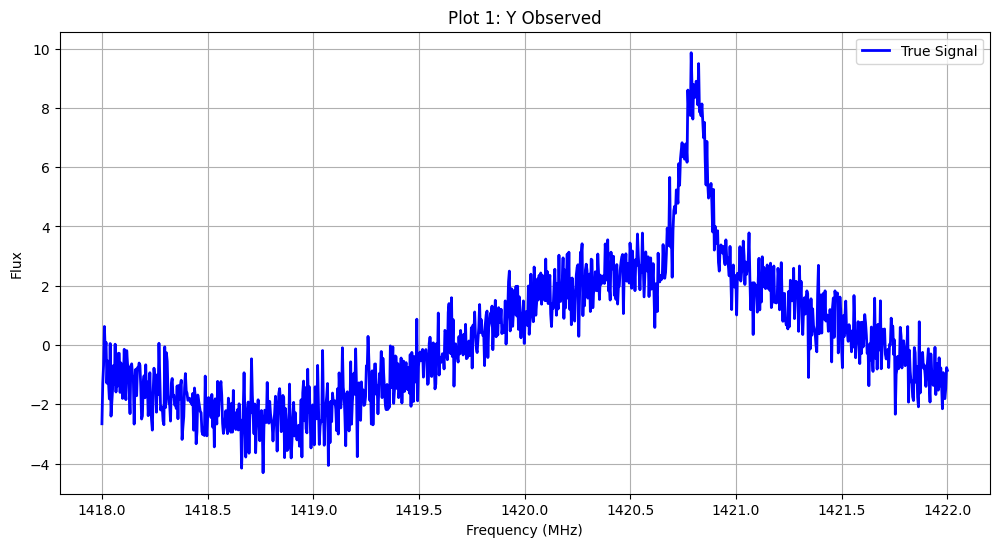

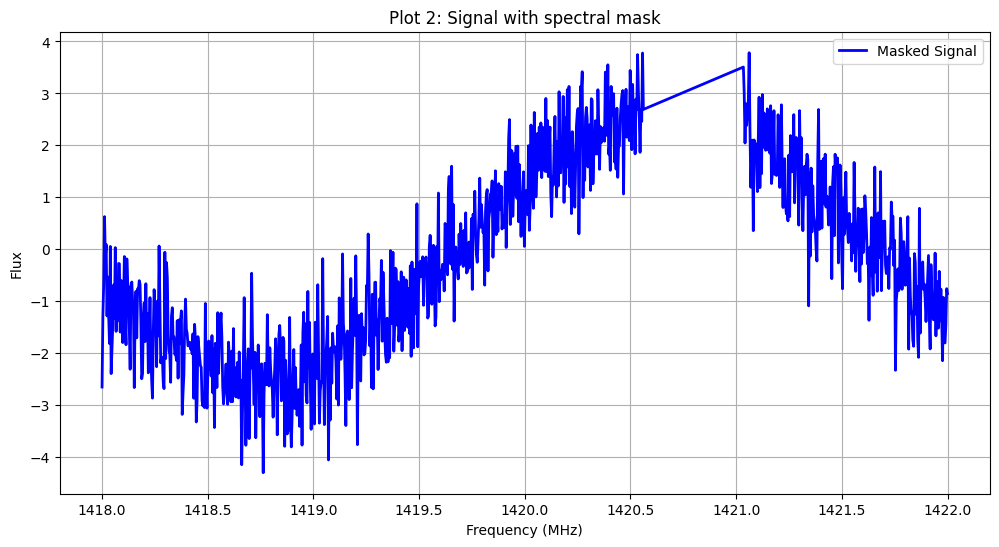

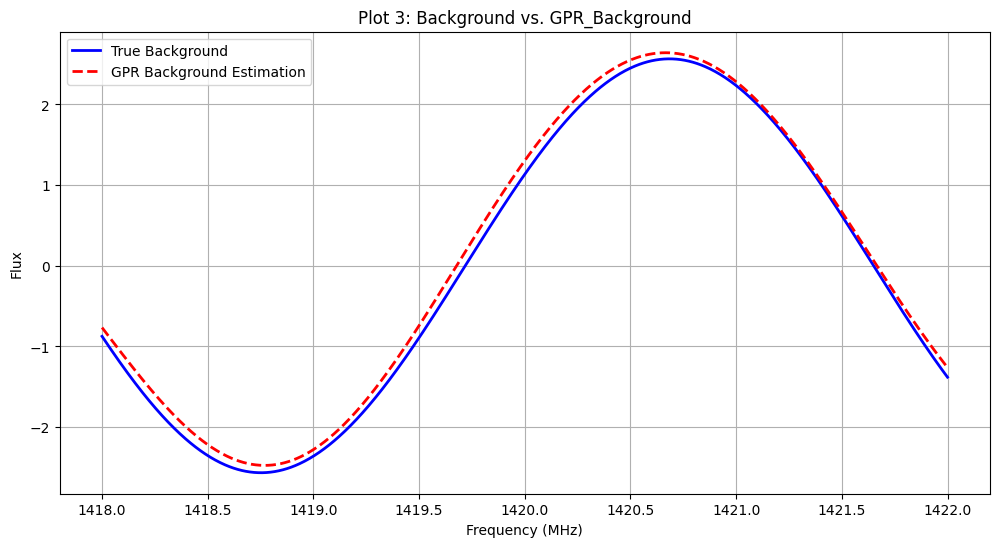

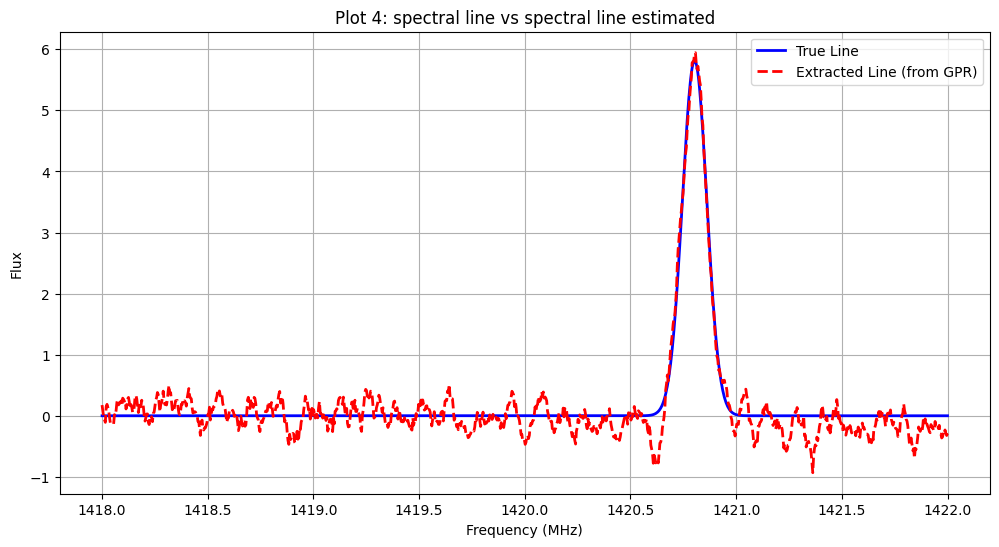

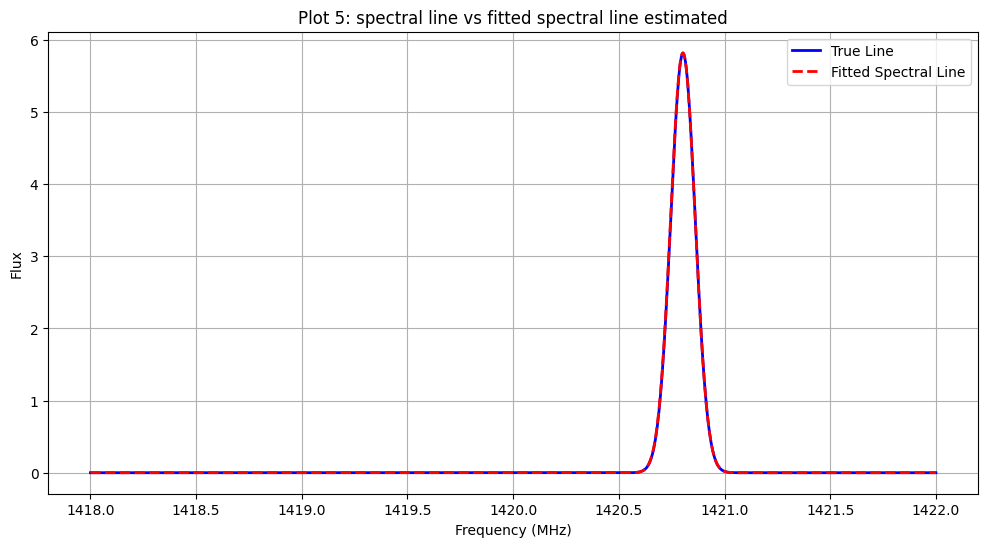

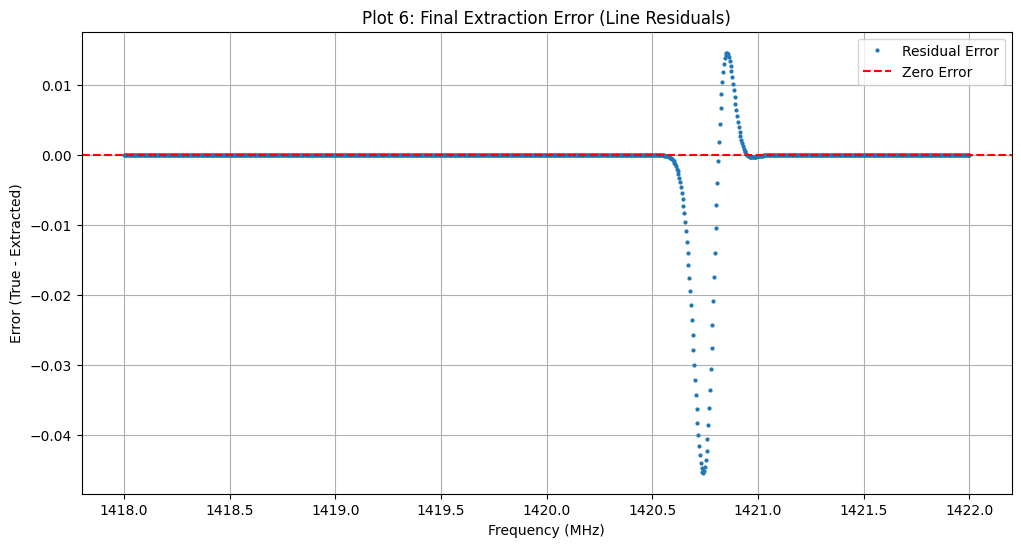

p0 = [np.float64(9.212577847279276), np.float64(1418.8993157380255), 0.05]
[9.16500314e+00 1.41888438e+03 7.99278029e-02]


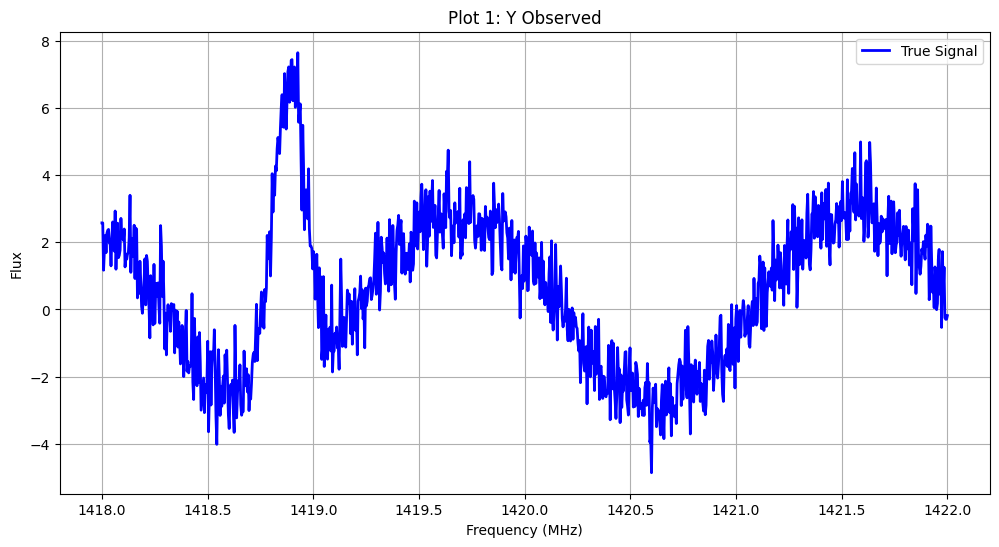

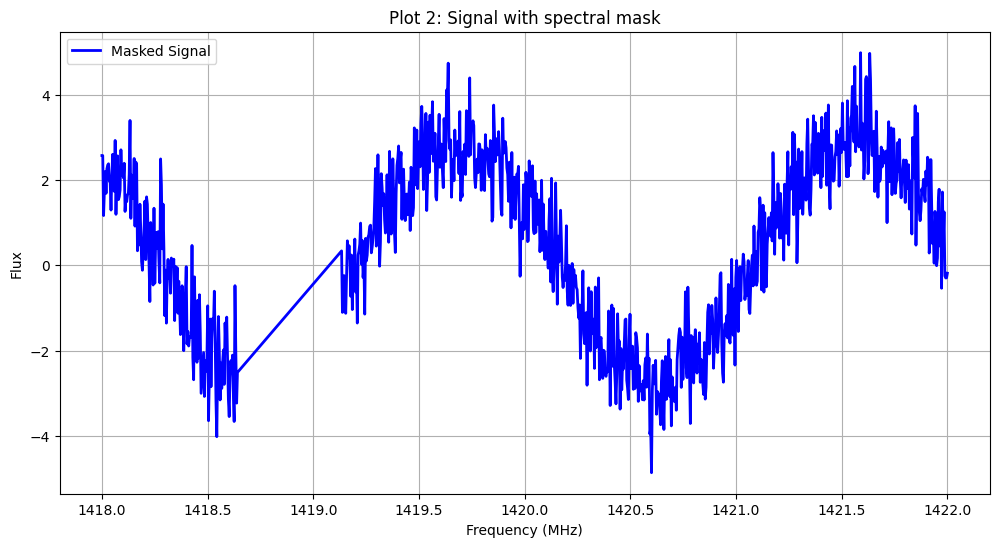

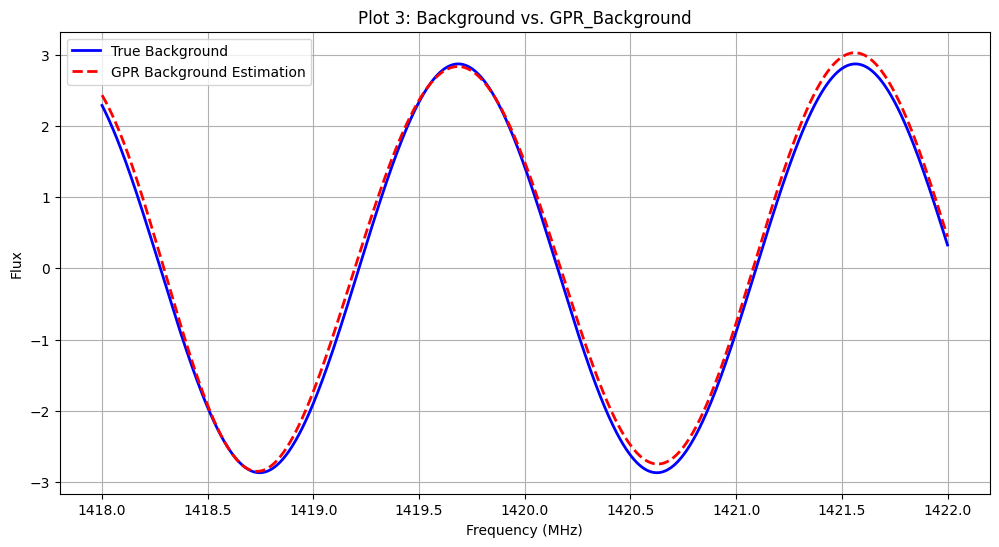

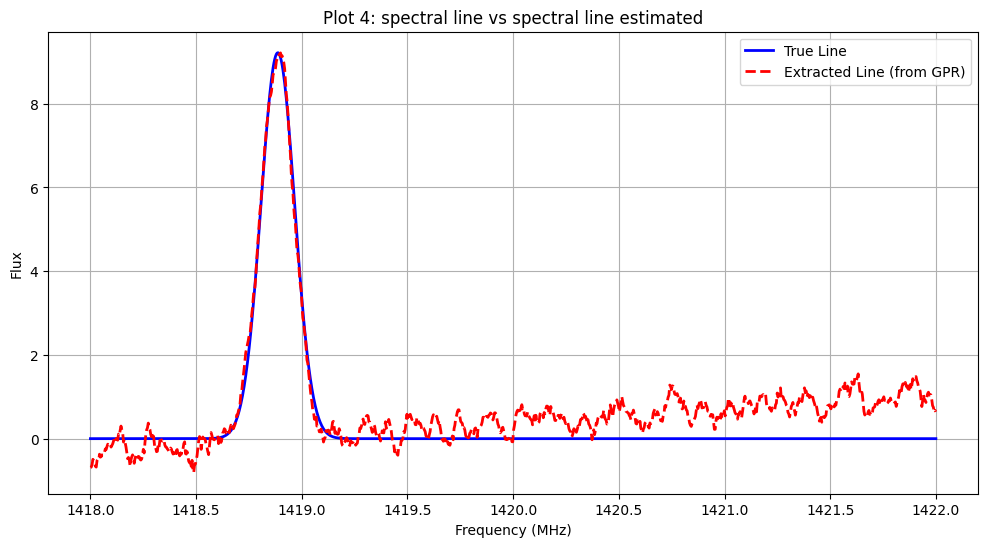

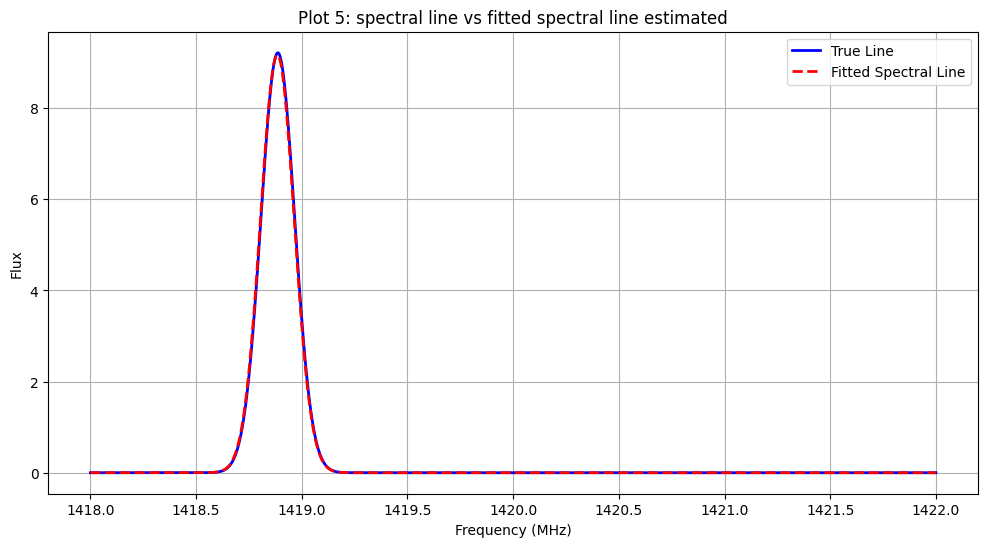

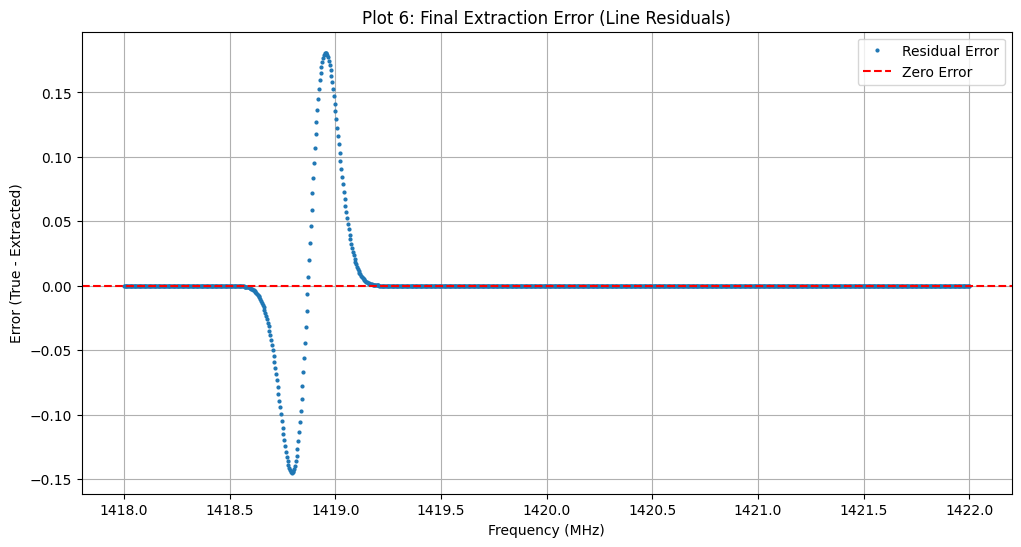

p0 = [np.float64(5.678215243427673), np.float64(1419.0869990224828), 0.05]
[5.66902832e+00 1.41909608e+03 6.45507762e-02]


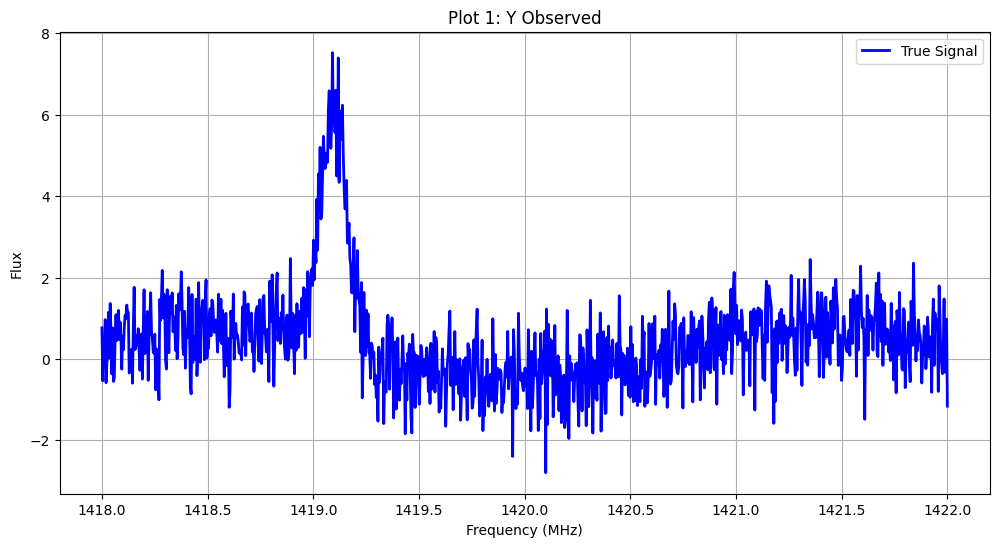

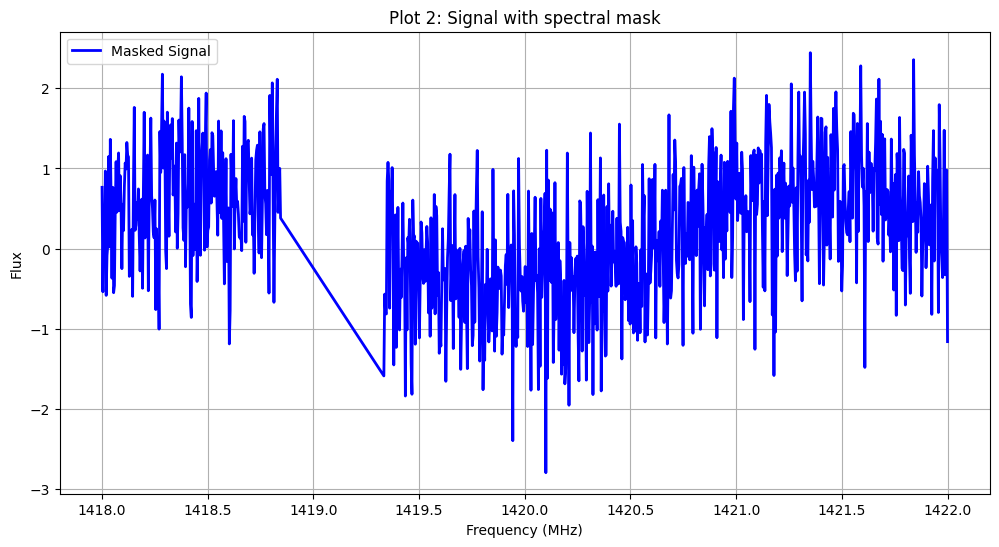

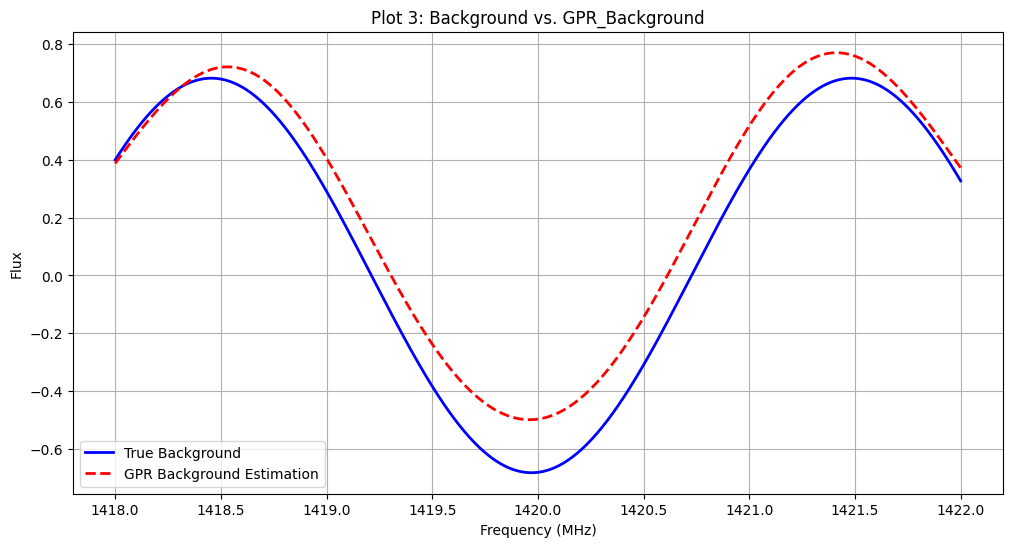

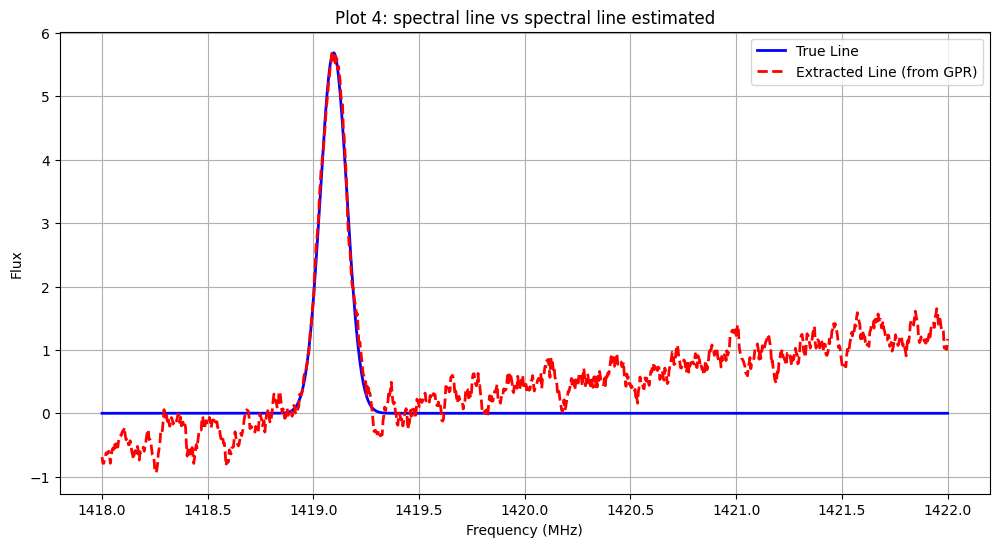

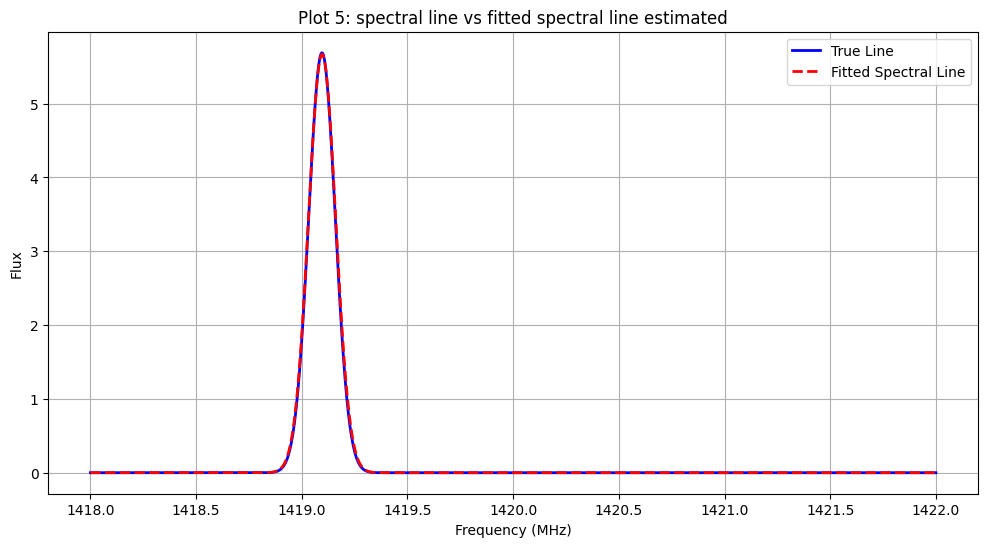

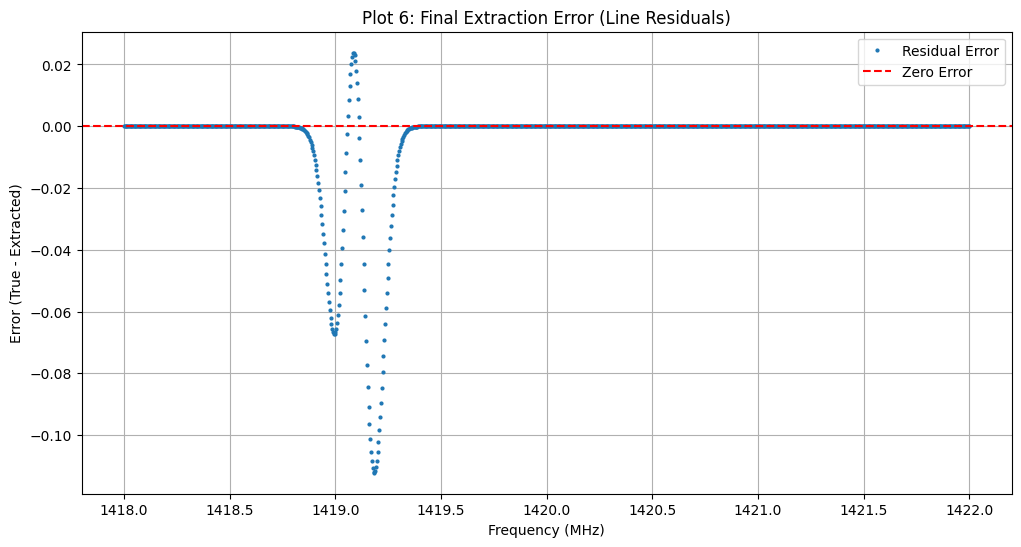

p0 = [np.float64(5.133410024978666), np.float64(1420.1075268817203), 0.05]
[4.84325620e+00 1.42010886e+03 7.11549248e-02]


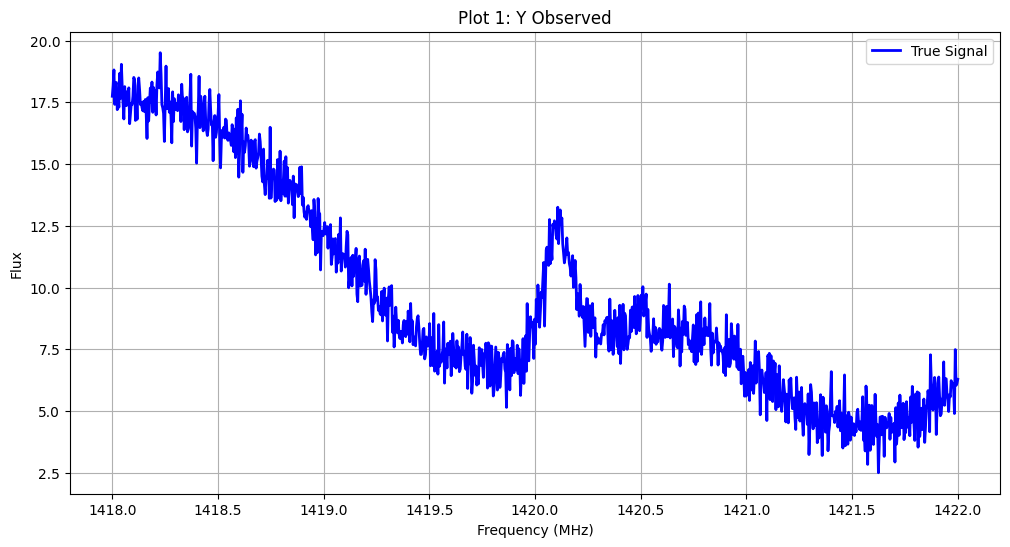

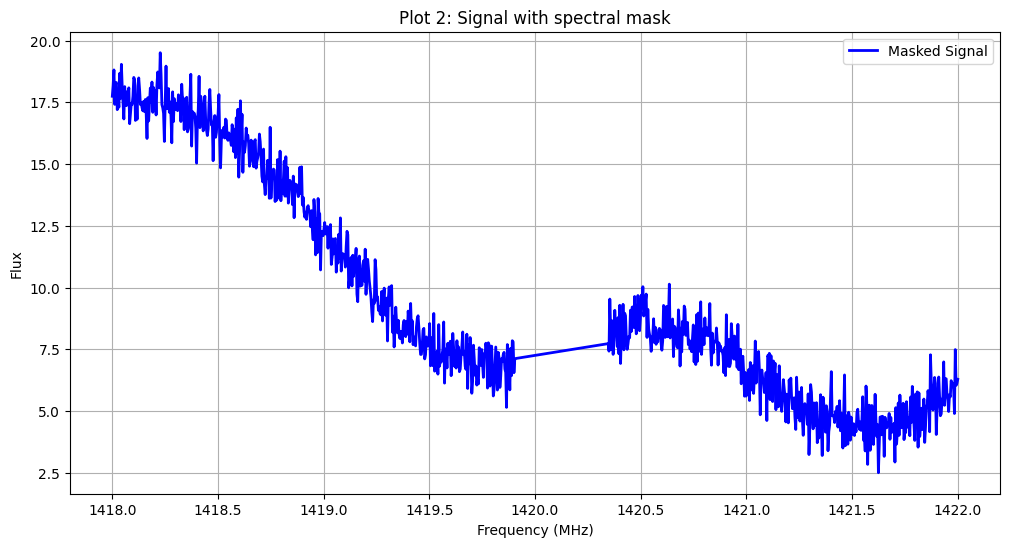

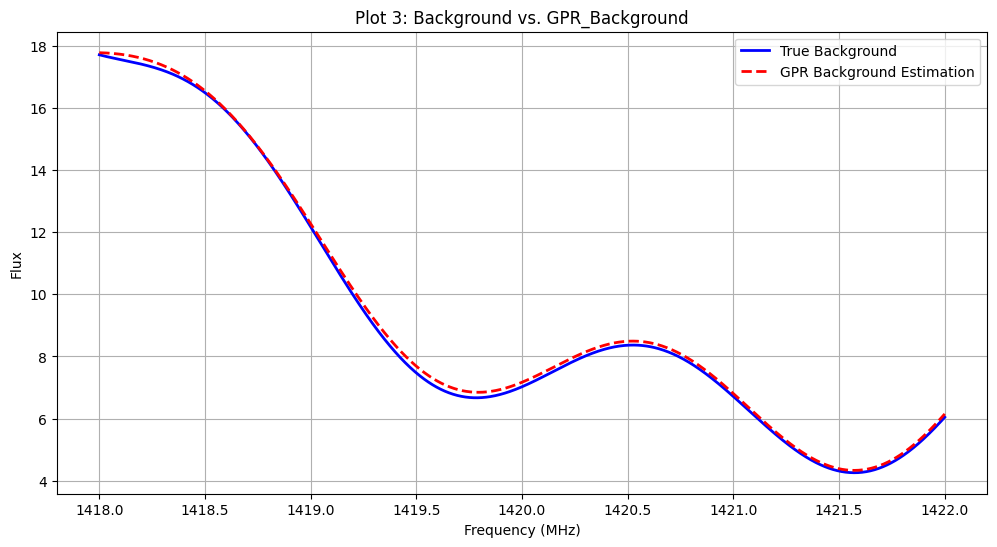

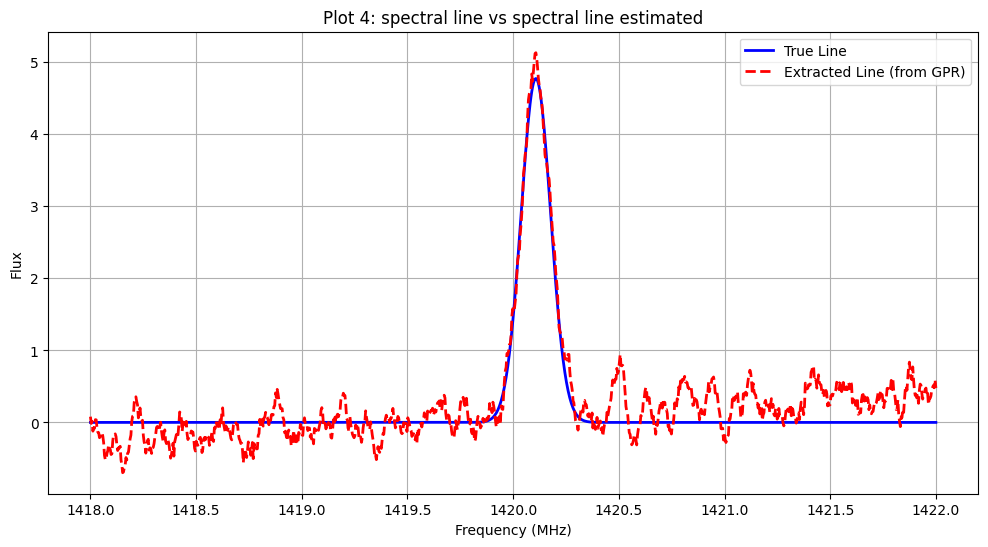

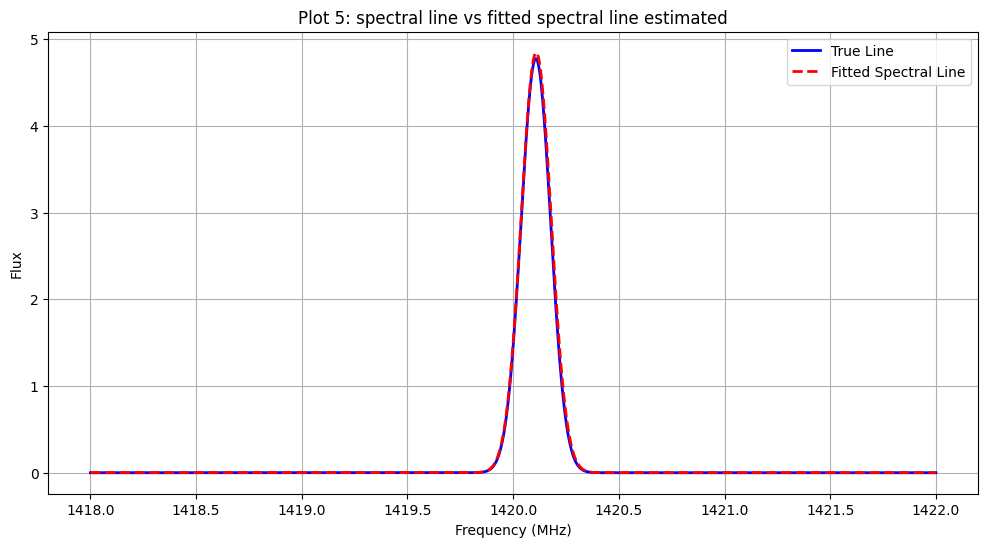

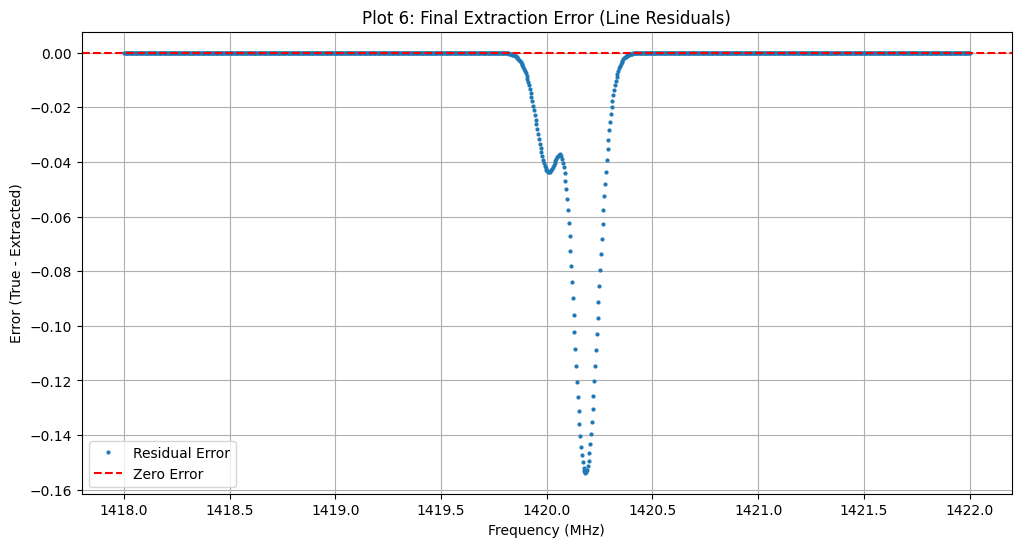

p0 = [np.float64(7.062467015058781), np.float64(1418.55522971652), 0.05]
[7.05296577e+00 1.41856187e+03 6.39901276e-02]


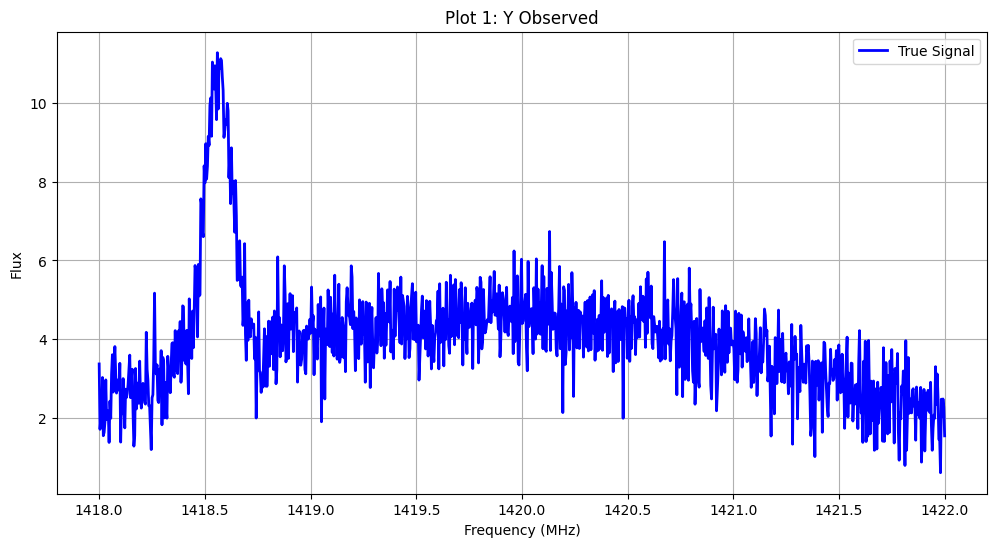

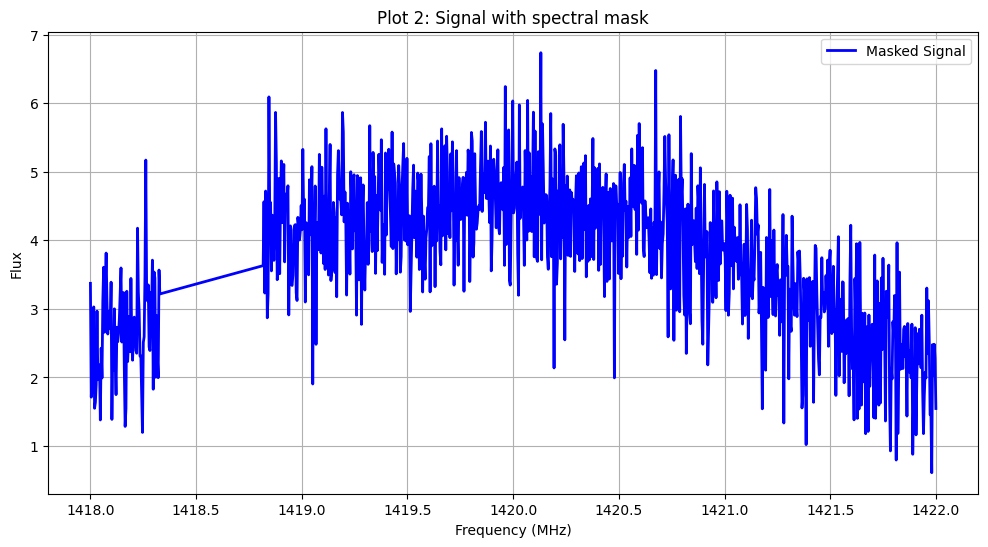

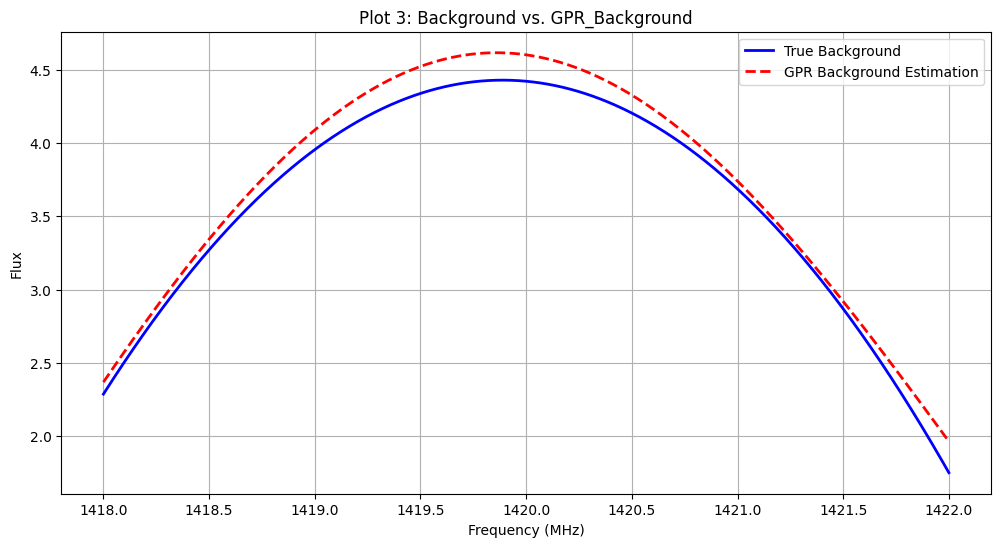

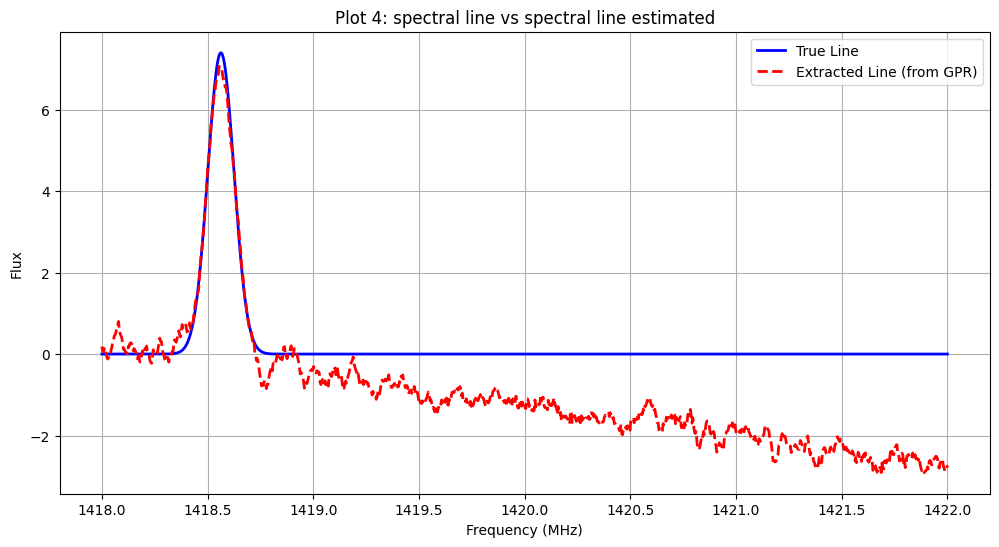

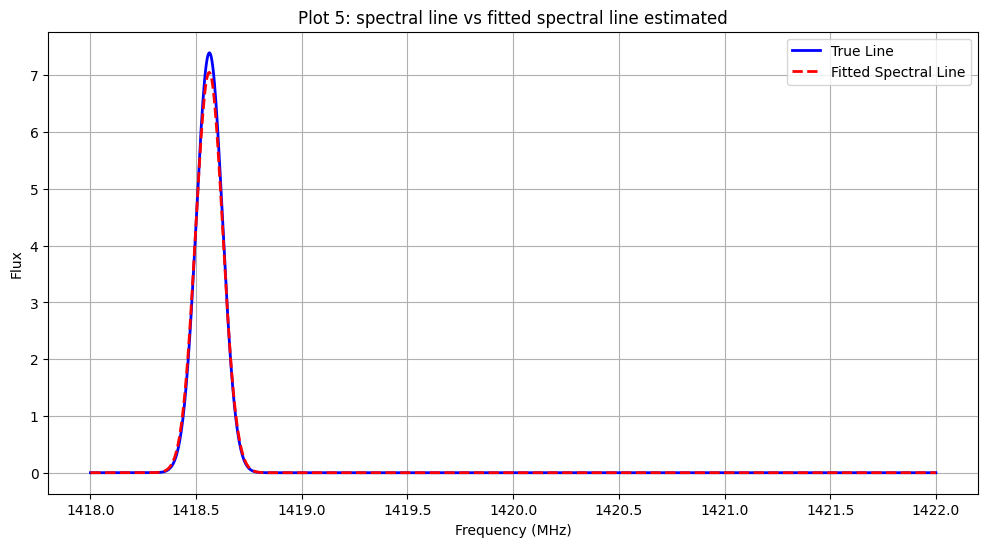

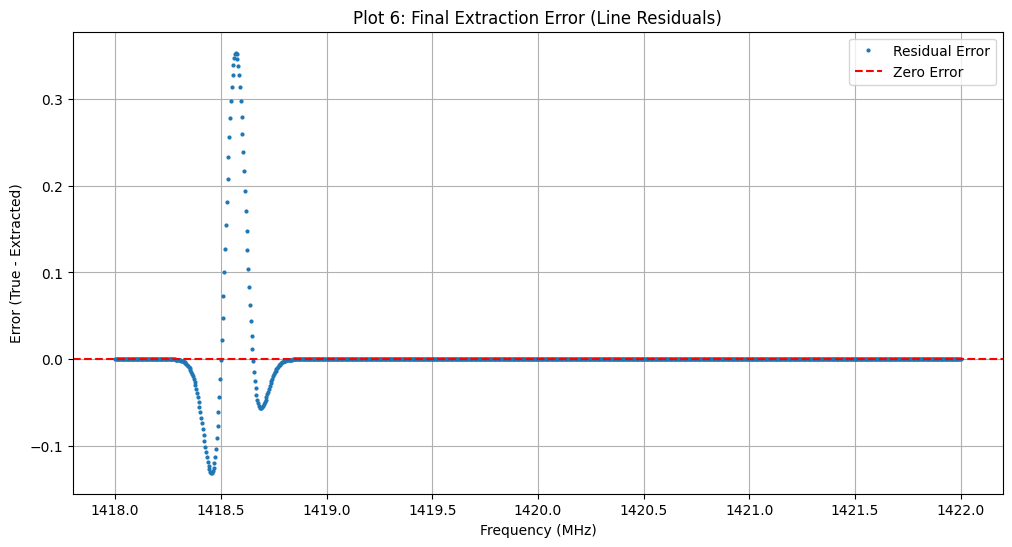

p0 = [np.float64(8.597700943587343), np.float64(1418.8054740957966), 0.05]
[8.46212056e+00 1.41879963e+03 6.67533489e-02]
p0 = [np.float64(7.816329708534017), np.float64(1420.3343108504398), 0.05]
[7.81515420e+00 1.42031909e+03 8.36425007e-02]
p0 = [np.float64(2.2486103610725157), np.float64(1419.2043010752689), 0.05]
[2.16816813e+00 1.41921799e+03 5.63578742e-02]
p0 = [np.float64(6.474330045979334), np.float64(1419.7869012707722), 0.05]
[6.49229073e+00 1.41978310e+03 5.03292562e-02]
p0 = [np.float64(7.830612159549162), np.float64(1419.3724340175952), 0.05]
[7.80019961e+00 1.41937225e+03 5.12613354e-02]


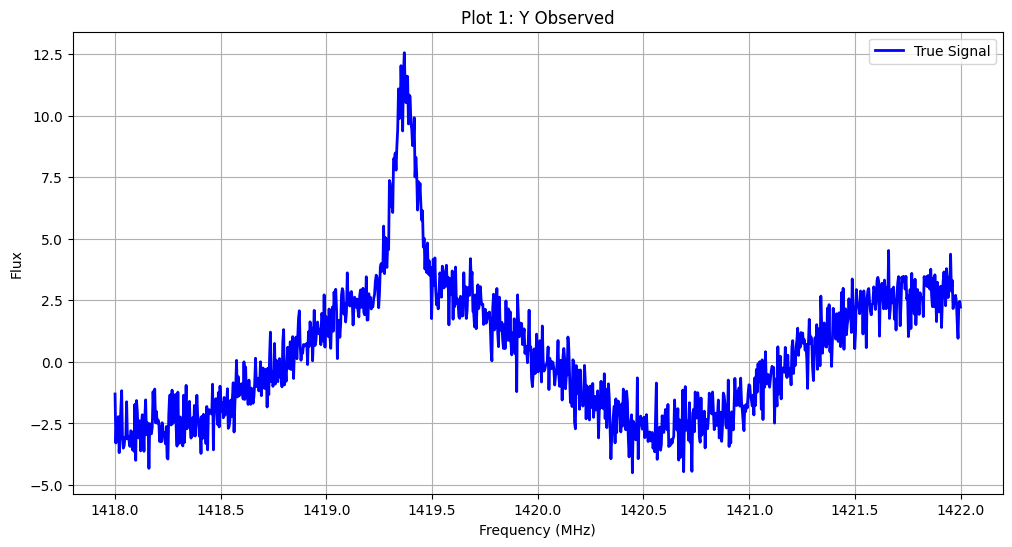

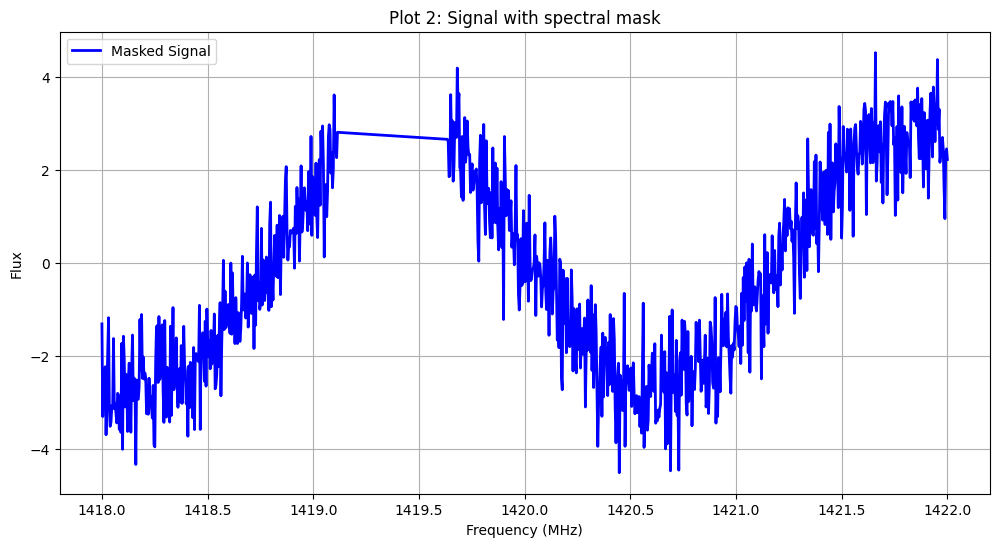

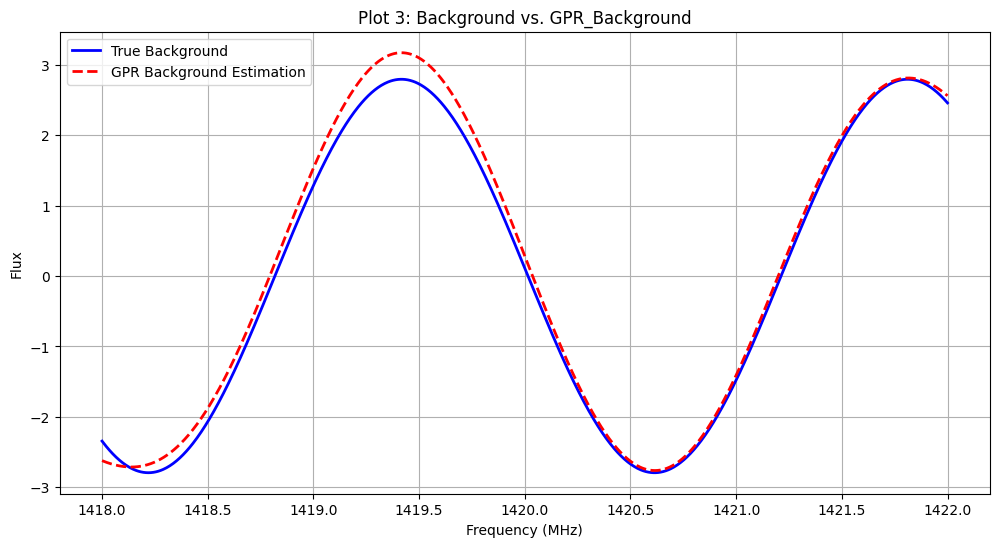

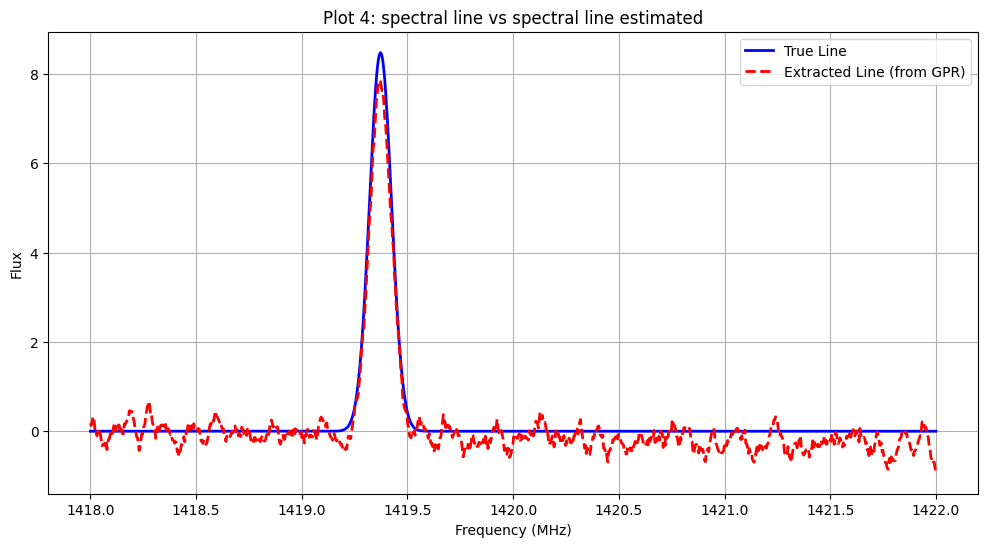

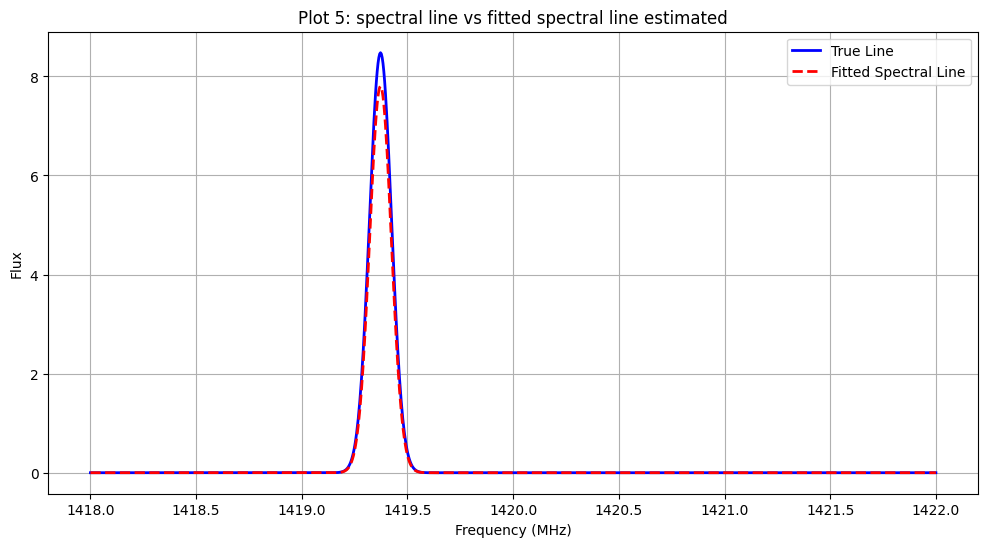

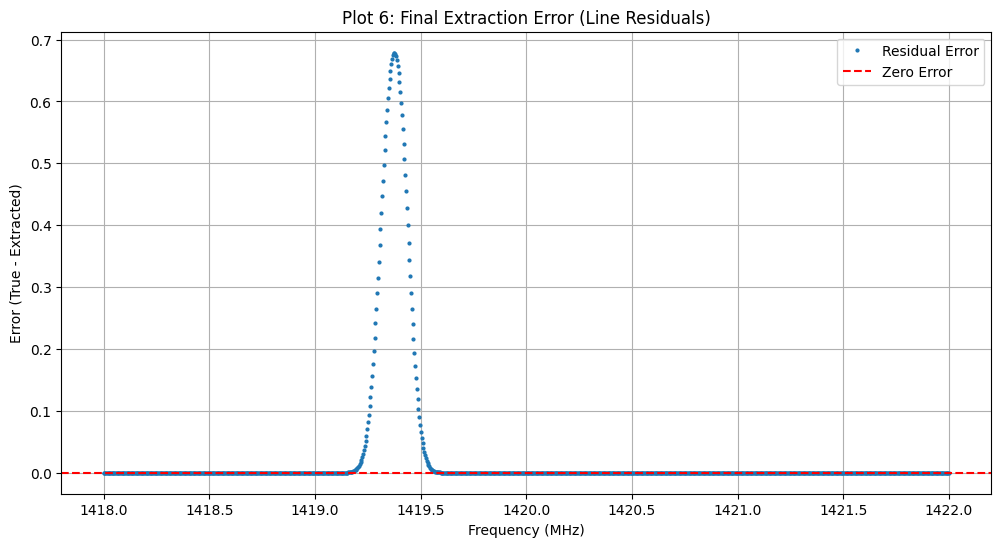

p0 = [np.float64(5.740715506801597), np.float64(1419.6539589442816), 0.05]
[5.55379561e+00 1.41963588e+03 8.98087877e-02]
p0 = [np.float64(8.661773905075622), np.float64(1418.6842619745846), 0.05]
[8.67807708e+00 1.41868143e+03 8.60804784e-02]
p0 = [np.float64(3.1872063212859314), np.float64(1419.1573802541545), 0.05]
[3.20060748e+00 1.41914731e+03 5.47449715e-02]
p0 = [np.float64(3.2201131676328942), np.float64(1419.126099706745), 0.05]
[2.98878380e+00 1.41911184e+03 6.57940050e-02]
p0 = [np.float64(7.804878498978983), np.float64(1419.5288367546432), 0.05]
[7.42149674e+00 1.41952907e+03 7.84982480e-02]
p0 = [np.float64(9.48542778776623), np.float64(1420.533724340176), 0.05]
[9.60878499e+00 1.42053487e+03 5.69795627e-02]
p0 = [np.float64(10.136164110905069), np.float64(1419.8572825024437), 0.05]
[1.00308276e+01 1.41985459e+03 8.85350198e-02]
p0 = [np.float64(3.9542423116610625), np.float64(1419.880742913001), 0.05]
[3.68665754e+00 1.41988158e+03 8.26121855e-02]
p0 = [np.float64(6.98871

In [72]:
time_res = []
res = []
random_to_plot=(0,1,2,3,4,5,6,7,8,9,10,15,45,80,95)
for i in range(30):
    # Frequencies axes
    frequencies = np.linspace(1418,1422,1024)
    # Create the signal and keep the background and specral line for evaluation purposes
    background , spectral_lines, y_observed = background_creation(freq=frequencies)
    thresh = 0.001

    start_time = time.time()
    mask = spectral_mask(y_observed=y_observed,freq=frequencies)

    # Mask the spectral line data
    X_train = frequencies[~mask].reshape(-1,1)
    y_train = y_observed[~mask]

    # Estimate the hyperparameters
    hyperparameters = []
    hyperparameters.append(estimate_hyperparameters(y_train,frequencies[1]-frequencies[0]))

    # Call the gpr algorithm and remove the background
    baseline_gpr = gpr_algorithm(frequencies,X_train,y_train,hyperparameters)
    spectrals_estimated = y_observed - baseline_gpr
    spectrals_estimated_corrected = spectrals_estimated - calculate_baseline_error(frequencies,spectrals_estimated,mask)

    # Smooth the extracted signal
    spectrals_estimated_smooth = uniform_filter1d(spectrals_estimated_corrected,size=11)

    spectral_fitted = gaussian_fit(frequencies,spectrals_estimated_smooth)
    time_res.append(time.time() - start_time)

    rmse_line = np.sqrt(mean_squared_error(spectral_lines, spectral_fitted))
    r2_line = r2_score(spectral_lines, spectral_fitted)
    mae_line = mean_absolute_error(spectral_lines, spectral_fitted)

    res.append((rmse_line,r2_line,mae_line))

    if i in random_to_plot:
        # --- Generate Plots ---

        # --- Plot 1: The Observation Signal ---
        plt.figure(figsize=(12, 6))
        plt.title("Plot 1: Y Observed")
        plt.plot(frequencies, y_observed, "b-", label="True Signal", linewidth=2)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Flux")
        plt.legend()
        plt.grid(visible=True)
        plt.show()

        # --- Plot 2: The Signal after the Masking ---
        plt.figure(figsize=(12, 6))
        plt.title("Plot 2: Signal with spectral mask")
        plt.plot(X_train, y_train, "b-", label="Masked Signal", linewidth=2)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Flux")
        plt.legend()
        plt.grid(visible=True)
        plt.show()

        # --- Plot 3: Comparison of real and GPR Background
        plt.figure(figsize=(12, 6))
        plt.title("Plot 3: Background vs. GPR_Background")
        plt.plot(frequencies, background, "b-", label="True Background", linewidth=2)
        plt.plot(frequencies, baseline_gpr, "r--", label="GPR Background Estimation", linewidth=2)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Flux")
        plt.legend()
        plt.grid(visible=True)
        plt.show()

        # --- Plot 4: Comparison of real and etimated Spectral line
        plt.figure(figsize=(12, 6))
        plt.title("Plot 4: spectral line vs spectral line estimated")
        plt.plot(frequencies, spectral_lines, "b-", label="True Line", linewidth=2)
        plt.plot(frequencies, spectrals_estimated_smooth, "r--", label="Extracted Line (from GPR)", linewidth=2)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Flux")
        plt.legend()
        plt.grid(visible=True)
        plt.show()

        # --- Plot 5: Comparison of real and etimated Spectral line Fitted
        plt.figure(figsize=(12, 6))
        plt.title("Plot 5: spectral line vs fitted spectral line estimated")
        plt.plot(frequencies, spectral_lines, "b-", label="True Line", linewidth=2)
        plt.plot(frequencies, spectral_fitted, "r--", label="Fitted Spectral Line", linewidth=2)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Flux")
        plt.legend()
        plt.grid(visible=True)
        plt.show()

        # --- Plot 6: Line Residuals
        line_residuals = spectral_lines - spectral_fitted
        plt.figure(figsize=(12, 6))
        plt.title("Plot 6: Final Extraction Error (Line Residuals)")
        plt.plot(frequencies, line_residuals, "o", markersize=2, label="Residual Error")
        plt.axhline(0, color="red", linestyle="--", label="Zero Error")
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("Error (True - Extracted)")
        plt.legend()
        plt.grid(visible=True)
        plt.show()



time_res = np.array(time_res)
print(f"Mean Duration = {np.mean(time_res):.4f} sec.")
rmse_sum = 0
r2_sum = 0
mse_sum = 0
for a,b,c in res:
    rmse_sum+=a
    r2_sum += b
    mse_sum += c

print(f"The mean ROOT MEAN SQUARED ERROR is: {rmse_sum*100/30:.4f}%")
print(f"The mean R2 Score is: {r2_sum *100/30:.4f}%")
print(f"The mean MEAN SQUARED ERROR is: {mse_sum*100/30:.4f}%")